(mmm_yoy_target_transform)=
# Year-over-Year Target Transform: a Custom MMM for Highly Seasonal KPIs

For KPIs whose variance is dominated by an annual cycle, a useful reparameterisation is to stop
modelling the level and model the **year-over-year ratio** instead. The prior cycle's observed
level becomes the seasonal baseline, so seasonality enters multiplicatively and for free: no
Fourier basis, no trend component, no per-unit seasonal profile to estimate.

This notebook builds that model from scratch with plain PyMC plus PyMC-Marketing components,
following the strategy of {ref}`mmm_components` and {ref}`mmm_custom_splines`. We generate the
data from a generative PyMC model in the style of {ref}`mmm_data_generator`, fit the
year-over-year model, fit level-space {class}`~pymc_marketing.mmm.mmm.MMM` models with Fourier
seasonality on the same panel, and compare them out of sample against the baselines that tell us
where the gain actually comes from.

The transform is cheap to implement, but it is not just a preprocessing step: it changes what the
likelihood can identify, and therefore what a "channel contribution" number means. A large part
of this notebook is about that.

**Roadmap**

1. The transform, and the **reference map** $r(t)$ that makes it work with moving holidays.
2. A generative PyMC model for a highly seasonal, multi-unit panel.
3. The custom year-over-year model, built from `GeometricAdstock` and `LogisticSaturation`.
4. Level-space MMMs with Fourier seasonality on the same data.
5. Holdout comparison decomposed against a seasonal-naive baseline, parameter recovery, and the
   two contribution bases.
6. A second panel, generated *off* the transform's home turf, to see what the ratio model pays
   when the seasonal shape is fixed and the noise is independent.

```{tip}
*Why a custom model?*
The {class}`~pymc_marketing.mmm.mmm.MMM` class covers a lot of ground, but the year-over-year
transform touches `build_model`, not just preprocessing: every driver has to enter as a
**within-pair contrast**, and that differencing happens *after* adstock and saturation. Writing
it as a PyMC model keeps the structure visible. The PyMC-Marketing components still do the heavy
lifting, so there is no need to reimplement adstock or saturation.
```

## Prepare Notebook

In [1]:
from collections import Counter

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import pytensor.xtensor as ptx
import xarray as xr
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "mmm_yoy_target_transform"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## The transform

Let $y_{u,t}$ be the KPI for unit $u$ (store, region, product) at period $t$, and let $r(t)$ be a
**reference map** sending each period to its counterpart one cycle earlier. We model the ratio

$$
z_{u,t} \;=\; \frac{y_{u,t}}{y_{u,\,r(t)}}
$$

with an additive linear predictor in which every driver enters as a within-pair contrast

$$
z_{u,t} \;=\; \alpha_u
\;+\; \sum_c \bigl[f_c(a_{c,u,t}) - f_c(a_{c,u,\,r(t)})\bigr]
\;+\; \sum_k \gamma_k \bigl[x_{k,u,t} - x_{k,u,\,r(t)}\bigr]
\;+\; \varepsilon_{u,t},
$$

where $f_c$ is the usual adstock-then-saturation composition (in PyMC-Marketing the channel
coefficient lives inside $f_c$) and $x_k$ are controls in raw driver units. Levels are recovered
exactly by $y_{u,t} = y_{u,r(t)} \cdot z_{u,t}$.

Three things fall out immediately.

- **Seasonality is absorbed multiplicatively.** Any part of the seasonal shape that repeats cycle
  over cycle is already in $y_{u,r(t)}$. The model only has to explain departures from last cycle.
- **The per-unit baseline collapses to a scalar.** $\alpha_u$ is that unit's typical growth rate.
  There is no per-unit seasonal curve, which is where most of the parameters in a level-space
  panel MMM go.
- **Noise is proportional, and the reference is noisy too.** Additive noise in ratio space is
  proportional noise in level space, which is usually closer to the truth for sales-like KPIs.
  But $y_{u,r(t)}$ is an observation, not a parameter: if the level noise is independent across
  cycles, the ratio carries roughly twice the noise variance of the level and is negatively
  correlated with the ratio one cycle earlier. The second panel at the end of the notebook
  measures both.

### The reference map is the interesting part

$r(t) = t - 52$ works only if the calendar repeats exactly. It does not. Moving holidays (Easter,
Ramadan, Chinese New Year, Thanksgiving-relative weeks) shift by a variable number of weeks, and
a blind 52-week lag pairs a holiday week against a non-holiday week, injecting a spurious spike
into $z$ precisely where the KPI is largest. So $r$ has to be **event-anchored**, with a shoulder
window around each moving anchor so that the weeks on either side of the event travel with it.

The obvious implementation, dragging the current event window onto the prior event window and
leaving every other period on the base 52-week lag, has a defect that is easy to miss. If the
event moved by $k$ periods and $|k| > \text{pad}$, the current period that sits exactly 52 weeks
after the *prior* holiday is a normal week, and it keeps its base reference: the prior holiday.
The prior holiday is then the reference for two current periods, one of which is not a holiday,
and $k$ prior periods are the reference for nothing. A normal week divided by a holiday week is a
crater in $z$, which is exactly the artifact anchoring was supposed to remove, only displaced.

The fix is to treat the realignment as a **permutation** of the prior cycle rather than a shift.
Take the prior-cycle segment spanned by the two windows and rotate it by $k$: the anchor block
lands on the prior anchor block, and the $k$ displaced periods fill the slots the block vacated.
$r$ stays a bijection between consecutive cycles, so there are no duplicated or orphaned
reference periods, every holiday is paired with a holiday, and cycle-level roll-ups of
$y_{u,r(t)}$ equal the prior-cycle total. The price is that the displaced periods pair with a
week up to $2\,\text{pad} + 1$ periods away, which on a smooth seasonal shape costs a few percent
rather than a holiday-sized spike.

In [2]:
def build_reference_map(
    n_periods: int,
    period: int,
    anchors: tuple[tuple[int, int], ...] = (),
    pad: int = 0,
) -> tuple[np.ndarray, list[int], list[int]]:
    """Map each period to its counterpart one cycle earlier.

    Moving events are realigned by rotating the prior-cycle segment spanned by the current and
    prior event windows, so the map stays a bijection between consecutive cycles.

    Parameters
    ----------
    n_periods : int
        Length of the full series.
    period : int
        Base cycle length, e.g. 52 for weekly data.
    anchors : tuple of (current, prior) index pairs
        Consecutive occurrences of a moving event. ``current`` is the index of an occurrence and
        ``prior`` the index of the occurrence before it, which must be about one cycle earlier
        (within half a cycle of ``current - period``). Windows of different anchors must not
        overlap. Both conditions raise ``ValueError`` when violated.
    pad : int
        Number of shoulder periods on each side of an anchor that travel with it.

    Returns
    -------
    reference : np.ndarray
        ``reference[t]`` is the index of the reference period for ``t``, negative where no
        reference exists (the first cycle).
    duplicated : list of int
        Prior-cycle periods used as the reference for more than one current period. Empty
        whenever the anchors satisfy the contract above; returned so the caller can check.
    orphaned : list of int
        Prior-cycle periods that are the reference for nothing. Empty under the same condition.
    """
    reference = np.arange(n_periods) - period
    rotated_periods: set[int] = set()

    for current, prior in anchors:
        shift = (current - period) - prior
        if abs(shift) > period // 2:
            raise ValueError(
                f"anchor {(current, prior)} pairs occurrences {current - prior} periods apart; "
                "each anchor must pair an occurrence with the one about one cycle earlier"
            )
        if shift == 0:
            continue
        low = min(prior, prior + shift) - pad
        high = max(prior, prior + shift) + pad
        if low < 0:
            raise ValueError(
                f"anchor {(current, prior)}: event window starts before the series"
            )
        segment = np.arange(low, high + 1)
        if rotated_periods.intersection(segment.tolist()):
            raise ValueError(
                f"anchor {(current, prior)}: event window overlaps another anchor's"
            )
        rotated_periods.update(segment.tolist())
        for base, rotated in zip(segment, np.roll(segment, shift), strict=True):
            t = base + period
            if 0 <= t < n_periods:
                reference[t] = rotated

    used = reference[reference >= 0]
    counts = Counter(used.tolist())
    duplicated = sorted(p for p, n in counts.items() if n > 1)
    orphaned = sorted(set(range(n_periods - period)) - set(used.tolist()))
    return reference, duplicated, orphaned

## Synthetic data

We build a weekly panel of four stores over six years. The design is deliberately friendly to the
ratio model and hostile to a level-space one, so that the comparison isolates the mechanism rather
than the tuning:

- a strong annual seasonal shape that is **inherited** cycle over cycle rather than re-drawn,
- a **moving holiday** with a three-week profile (a pre-holiday shoulder, the peak, and a
  post-holiday shoulder) whose week-of-year drifts by up to three weeks,
- three media channels, one of which is held at a **flat always-on plan** (constant spend, so its
  year-over-year contrast is exactly zero), and
- **proportional** observation noise.

We come back to the fairness of that choice in the comparison and again with a second panel.

In [3]:
n_years = 6
period = 52
n_dates = n_years * period

date_index = pd.date_range(start="2019-01-07", freq="W-MON", periods=n_dates)

unit_names = ["north", "south", "east", "west"]
channel_columns = ["tv", "search", "sponsorship"]
control_columns = ["discount"]

l_max = 8

coords_data = {
    "date": date_index,
    "unit": unit_names,
    "channel": channel_columns,
    "control": control_columns,
}

n_units = len(unit_names)
n_channels = len(channel_columns)

# The moving holiday: week-of-year of the event in each of the six cycles, and its three-week
# multiplicative profile (the week before, the holiday itself, the week after).
holiday_week_of_year = [12, 13, 15, 14, 12, 13]
holiday_index = [period * y + w for y, w in enumerate(holiday_week_of_year)]
holiday_profile = np.array([1.15, 1.55, 1.10])
holiday_offsets = np.arange(-1, 2)

print(f"holiday period index per cycle: {holiday_index}")

holiday period index per cycle: [12, 65, 119, 170, 220, 273]


### Reference map for this calendar

Each cycle's holiday is anchored to the previous cycle's holiday, with a one-week shoulder on each
side, matching the width of the holiday profile. The printed diagnostics are the check that the
map did what the previous section promised, not decoration: with a bijective map both lists are
empty and no holiday week is paired against a normal one.

In [4]:
anchors = tuple(zip(holiday_index[1:], holiday_index[:-1], strict=True))

reference_map, duplicated, orphaned = build_reference_map(
    n_periods=n_dates, period=period, anchors=anchors, pad=1
)
naive_reference_map, _, _ = build_reference_map(n_periods=n_dates, period=period)

holiday_weeks = np.add.outer(holiday_index, holiday_offsets).ravel()
has_reference = reference_map >= 0
mismatched_pairs = np.flatnonzero(
    has_reference
    & (
        np.isin(np.arange(n_dates), holiday_weeks)
        != np.isin(reference_map, holiday_weeks)
    )
)

event_moves = [abs((current - period) - prior) for current, prior in anchors]
max_displacement = np.abs(
    reference_map[has_reference] - naive_reference_map[has_reference]
).max()

print(f"anchors (current <- prior):                    {anchors}")
print(f"duplicated reference periods:                  {duplicated}")
print(f"orphaned reference periods:                    {orphaned}")
print(f"holiday weeks paired with normal weeks or v.v.: {mismatched_pairs.tolist()}")
print(f"event realignment per anchor |k|:              {event_moves} weeks")
print(
    f"displacement of the weeks a window pushes aside: 2 * pad + 1 = {2 * 1 + 1} weeks"
)
print(f"max |r(t) - (t - 52)| over the series:         {max_displacement} weeks")

anchors (current <- prior):                    ((65, 12), (119, 65), (170, 119), (220, 170), (273, 220))
duplicated reference periods:                  []
orphaned reference periods:                    []
holiday weeks paired with normal weeks or v.v.: []
event realignment per anchor |k|:              [1, 2, 1, 2, 1] weeks
displacement of the weeks a window pushes aside: 2 * pad + 1 = 3 weeks
max |r(t) - (t - 52)| over the series:         3 weeks


Let us look at the seam directly, around the third cycle's holiday, which moved two weeks later
than the second cycle's.

In [5]:
window = np.arange(holiday_index[2] - 5, holiday_index[2] + 4)

seam_df = pd.DataFrame(
    {
        "period t": window,
        "base r(t) = t - 52": naive_reference_map[window],
        "anchored r(t)": reference_map[window],
        "displacement": reference_map[window] - naive_reference_map[window],
        "t in holiday window": np.isin(window, holiday_weeks),
        "r(t) in holiday window": np.isin(reference_map[window], holiday_weeks),
    }
).set_index("period t")

seam_df

,base r(t) = t - 52,anchored r(t),displacement,t in holiday window,r(t) in holiday window
period t,,,,,
114,62,62,0,False,False
115,63,63,0,False,False
116,64,67,3,False,False
117,65,68,3,False,False
118,66,64,-2,True,True
119,67,65,-2,True,True
120,68,66,-2,True,True
121,69,69,0,False,False
122,70,70,0,False,False


The base map sends the holiday week 119 to the non-holiday week 67, and, just as damaging, sends
the normal week 117 to the holiday week 65. The rotated map pairs the three-week holiday window
`118..120` with `64..66`, and the two displaced weeks `116` and `117` take the two prior-cycle
weeks the window vacated, `67` and `68`, three weeks away from their base reference. Every prior
period is used exactly once.

```{note}
Anchoring moves two groups of periods. The event window itself moves by $|k|$, the size of the
event's own shift, which is the point. The $|k|$ weeks it pushes aside move by $2\,\text{pad} + 1$
in the other direction, and that is the cost, so a shoulder should be as narrow as the event's
real footprint. For a one-week event `pad=0` displaces the pushed-aside weeks by one week; here
the holiday has a three-week profile, so `pad=1` is the right width. The printed maximum is the
larger of the two numbers, which here is the displaced-week cost because the holiday never moves
by more than two weeks.
```

### What the anchors have to satisfy

The builder takes anchors as index pairs of **consecutive occurrences**, and the rotation is only
meaningful when the two occurrences are about one cycle apart. That contract is checked, because
the convenient "one week-of-year per cycle" encoding used above can silently violate it: an event
in week 50 of one year and week 0 of the next is two weeks apart, not a year, and an event that
skips a calendar year is two years apart. Both would produce short-horizon ratios that look like
year-over-year ones.

What is *not* a problem is an event window that straddles the boundary between two cycles in the
index. A yearly event that drifts earlier by two weeks per occurrence passes from week 1 of one
year to week 51 of the same year, so that year has two occurrences and the window sits across the
index boundary; the rotation does not care, because it works on runs of consecutive periods, not
on calendar years.

In [6]:
drifting_event = [
    55,
    105,
    155,
    205,
    255,
    305,
]  # week 3, 1, 51, 49, 47, 45: two in cycle 2
drifting_anchors = tuple(zip(drifting_event[1:], drifting_event[:-1], strict=True))

drifting_map, drifting_duplicated, drifting_orphaned = build_reference_map(
    n_periods=n_dates, period=period, anchors=drifting_anchors, pad=1
)
drifting_lag = np.arange(period, n_dates) - drifting_map[period:]

print(f"duplicated: {drifting_duplicated}, orphaned: {drifting_orphaned}")
print(f"event -> reference: {[(t, int(drifting_map[t])) for t in drifting_event[1:]]}")
print(f"t - r(t) ranges over [{drifting_lag.min()}, {drifting_lag.max()}] weeks")

duplicated: [], orphaned: []
event -> reference: [(105, 55), (155, 105), (205, 155), (255, 205), (305, 255)]
t - r(t) ranges over [50, 55] weeks


In [7]:
# The same event encoded as one week-of-year per cycle pairs week 0 of cycle 2 with week 50 of
# cycle 1, two weeks earlier. The builder refuses rather than returning a two-week "year-over-year".
bad_index = [period * y + w for y, w in enumerate([48, 50, 0, 2, 4, 6])]
try:
    build_reference_map(
        n_periods=n_dates,
        period=period,
        anchors=tuple(zip(bad_index[1:], bad_index[:-1], strict=True)),
        pad=1,
    )
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: anchor (104, 102) pairs occurrences 2 periods apart; each anchor must pair an occurrence with the one about one cycle earlier


### Generating correlated channel spend

Media spend comes from a small PyMC model: a multivariate normal over channels with an LKJ prior
on the correlation structure (brands rarely move one channel at a time), per unit-channel
intercepts and trends, and a softplus to keep spend non-negative. The discount control is drawn
from a Beta.

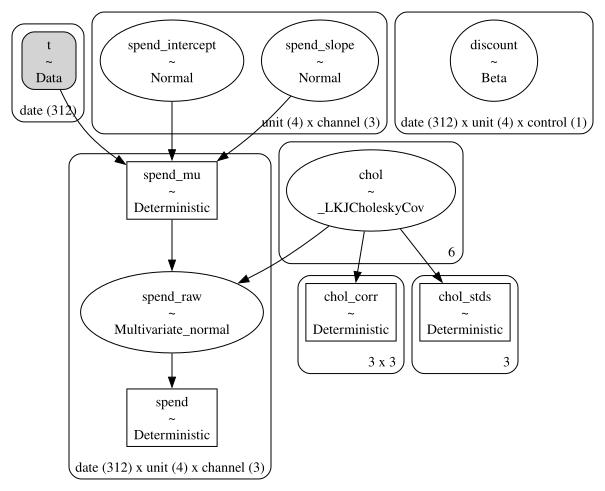

In [8]:
t_scaled = np.arange(n_dates) / n_dates

with pm.Model(coords=coords_data) as covariates_model:
    t_data = pm.Data("t", t_scaled, dims="date")

    chol, _, _ = pm.LKJCholeskyCov(
        "chol",
        n=n_channels,
        eta=3,
        sd_dist=pm.Exponential.dist(lam=1 / 1.5),
    )

    spend_intercept = pm.Normal(
        "spend_intercept", mu=0.0, sigma=0.7, dims=("unit", "channel")
    )
    spend_slope = pm.Normal("spend_slope", mu=0.0, sigma=0.7, dims=("unit", "channel"))

    spend_mu = pm.Deterministic(
        "spend_mu",
        spend_intercept + spend_slope * t_data[:, None, None],
        dims=("date", "unit", "channel"),
    )

    spend_raw = pm.MvNormal(
        "spend_raw", mu=spend_mu, chol=chol, dims=("date", "unit", "channel")
    )
    spend = pm.Deterministic(
        "spend", pt.softplus(spend_raw), dims=("date", "unit", "channel")
    )

    discount = pm.Beta(
        "discount", alpha=1.2, beta=6.0, dims=("date", "unit", "control")
    )

pm.model_to_graphviz(covariates_model)

In [9]:
spend_draw, discount_draw = pm.draw(
    [covariates_model["spend"], covariates_model["discount"]], draws=1, random_seed=rng
)

# The sponsorship channel is always-on at a flat plan: constant over time, hence identical
# cycle over cycle by construction.
sponsorship = channel_columns.index("sponsorship")
spend_draw[:, :, sponsorship] = spend_draw[:, :, sponsorship].mean(
    axis=0, keepdims=True
)

channel_data = xr.DataArray(
    spend_draw,
    dims=("date", "unit", "channel"),
    coords={"date": date_index, "unit": unit_names, "channel": channel_columns},
)
control_data = xr.DataArray(
    discount_draw,
    dims=("date", "unit", "control"),
    coords={"date": date_index, "unit": unit_names, "control": control_columns},
)

# Scale media to roughly [0, 1] once, up front, so that the ground-truth saturation parameters and
# all fitted models live on the same input scale.
channel_scale = channel_data.max(("date", "unit"))
channel_scaled = channel_data / channel_scale

channel_scaled.isel(date=slice(0, 3)).to_dataframe(name="scaled_spend").head()

scaled_spend
date       unit  channel                  
2019-01-07 north tv               0.697533
                 search           0.000024
                 sponsorship      1.000000
           south tv               0.241058
                 search           0.000126

Check the design. The sponsorship channel varies across units but not across time, so its
year-over-year contrast is exactly zero, while `tv` and `search` move.

In [10]:
spend_values = channel_scaled.transpose("date", "unit", "channel").to_numpy()

# Every period after the first cycle has a reference. The first ``l_max`` of those are dropped
# from the modelled window so that adstock has warmed up on both sides of every pair; they are
# still generated, because the level recursion needs them.
obs_idx_all = np.arange(period, n_dates)
obs_idx_model = np.arange(period + l_max, n_dates)

contrast_summary = pd.DataFrame(
    {
        "std of spend level": spend_values.std(axis=(0, 1)),
        "std of year-over-year spend contrast": (
            spend_values[obs_idx_model] - spend_values[reference_map[obs_idx_model]]
        ).std(axis=(0, 1)),
    },
    index=pd.Index(channel_columns, name="channel"),
)

contrast_summary

,std of spend level,std of year-over-year spend contrast
channel,,
tv,0.208739,0.254757
search,0.221408,0.319042
sponsorship,0.268643,0.000000


Text(0.5, 0.98, 'Media Spend by Channel and Unit')

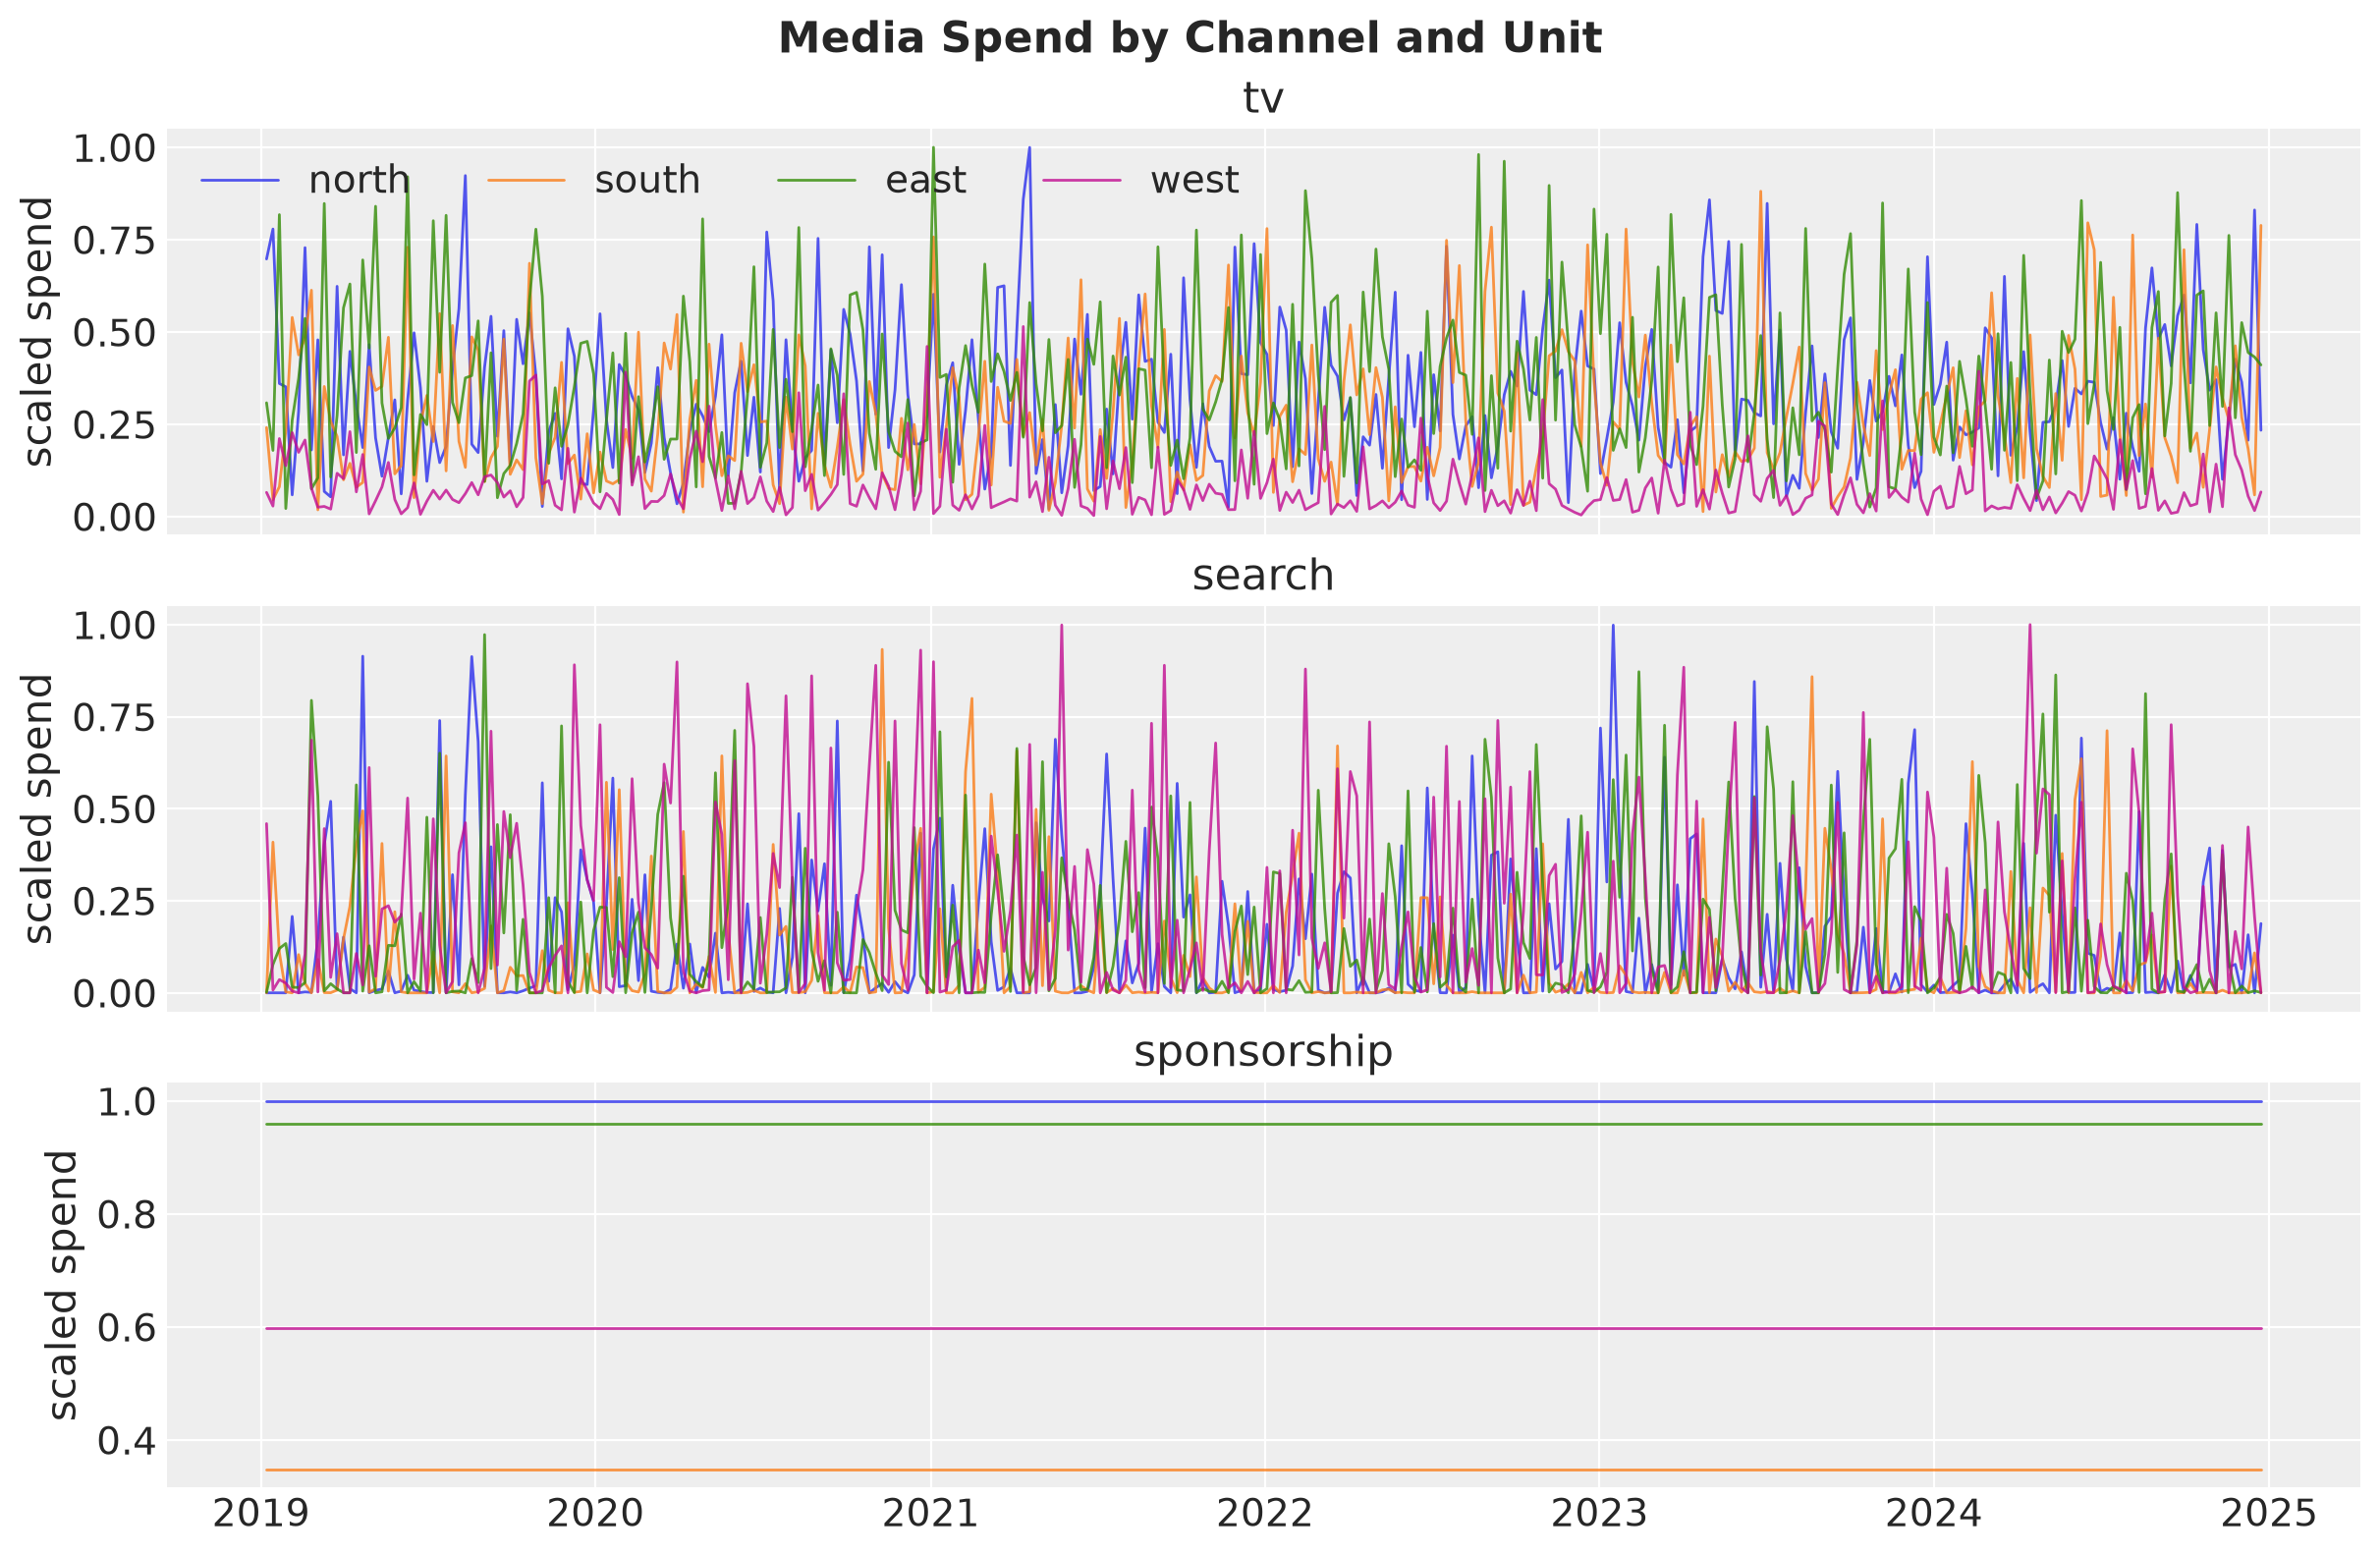

In [11]:
fig, axes = plt.subplots(
    nrows=n_channels, figsize=(12, 2.6 * n_channels), sharex=True, layout="constrained"
)

for ax, channel in zip(axes, channel_columns, strict=True):
    for unit in unit_names:
        ax.plot(
            date_index,
            channel_scaled.sel(channel=channel, unit=unit),
            alpha=0.8,
            linewidth=1,
            label=unit,
        )
    ax.set_title(channel)
    ax.set_ylabel("scaled spend")

axes[0].legend(loc="upper left", ncol=n_units)
fig.suptitle("Media Spend by Channel and Unit", fontsize=16, fontweight="bold")

### Ground-truth parameters

The saturation `beta` values are in **ratio points**: a full swing of `tv` moves the year-over-year
ratio by up to 0.13, that is 13 percent of the reference level. Note that the prior we will put on
`beta`, `HalfNormal(0.2)`, has a standard deviation of about 0.12, the same order as these values;
recovery is being tested with a prior that already knows the right scale.

In [12]:
adstock_alpha_true = np.array([0.55, 0.25, 0.40])
saturation_lam_true = np.array([2.5, 4.0, 3.0])
saturation_beta_true = np.array([0.13, 0.08, 0.06])
gamma_control_true = np.array([0.18])
intercept_true = np.array([1.03, 1.00, 0.98, 1.05])
z_sigma_true = np.array([0.030, 0.035, 0.028, 0.032])

media_truth = {
    "adstock_alpha": adstock_alpha_true,
    "saturation_lam": saturation_lam_true,
    "saturation_beta": saturation_beta_true,
}

ground_truth = pd.DataFrame(
    media_truth, index=pd.Index(channel_columns, name="channel")
)

ground_truth

,adstock_alpha,saturation_lam,saturation_beta
channel,,,
tv,0.55,2.5,0.13
search,0.25,4.0,0.08
sponsorship,0.40,3.0,0.06


## The year-over-year model

The model is wrapped in a function so that the *same* graph serves three purposes: data generation
(with the parameters clamped by {func}`pymc.do`), inference on the training window, and
out-of-sample prediction on a different observation window.

The one structural subtlety: $f_c$ is evaluated on the **full contiguous series** and only then
gathered at $t$ and $r(t)$. Gathering first and adstocking afterwards would build the reference
period's carryover out of the current period's history, which is wrong.

In [13]:
adstock = GeometricAdstock(
    l_max=l_max,
    priors={"alpha": Prior("Beta", alpha=1, beta=3, dims="channel")},
)

saturation = LogisticSaturation(
    priors={
        "lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
        "beta": Prior("HalfNormal", sigma=0.2, dims="channel"),
    }
)

In [14]:
def build_yoy_model(
    obs_idx: np.ndarray,
    z_observed: xr.DataArray | None = None,
) -> pm.Model:
    """Build the year-over-year ratio model on a given observation window."""
    ref_idx = reference_map[obs_idx]
    if np.any(ref_idx < 0):
        raise ValueError("every modelled period needs a reference period")

    coords = {
        "date": date_index,
        "obs_date": date_index[obs_idx],
        "unit": unit_names,
        "channel": channel_columns,
        "control": control_columns,
    }

    if z_observed is None:
        z_observed = xr.DataArray(
            np.ones((len(obs_idx), n_units)),
            dims=("obs_date", "unit"),
            coords={"obs_date": coords["obs_date"], "unit": unit_names},
        )

    with pm.Model(coords=coords) as model:
        channel_data_ = pmd.Data("channel_data", channel_scaled)
        control_data_ = pmd.Data("control_data", control_data)

        t_sel = ptx.as_xtensor(obs_idx, dims=("obs_date",))
        r_sel = ptx.as_xtensor(ref_idx, dims=("obs_date",))

        # Adstock then saturation on the whole series, shared parameters, and only then gather.
        f_full = saturation.apply(adstock.apply(channel_data_, core_dim="date"))

        f_current = pmd.Deterministic(
            "f_current",
            f_full.isel(date=t_sel),
            dims=("obs_date", "unit", "channel"),
        )
        f_reference = pmd.Deterministic(
            "f_reference",
            f_full.isel(date=r_sel),
            dims=("obs_date", "unit", "channel"),
        )
        channel_contribution = pmd.Deterministic(
            "channel_contribution",
            f_current - f_reference,
            dims=("obs_date", "unit", "channel"),
        )

        # Controls enter as raw driver differences through a linear coefficient.
        gamma_control = pmd.Normal("gamma_control", mu=0.0, sigma=0.5, dims="control")
        control_contribution = pmd.Deterministic(
            "control_contribution",
            gamma_control
            * (control_data_.isel(date=t_sel) - control_data_.isel(date=r_sel)),
            dims=("obs_date", "unit", "control"),
        )

        # The per-unit baseline is a scalar: that unit's typical growth rate.
        intercept = pmd.Normal("intercept", mu=1.0, sigma=0.15, dims="unit")

        mu = pmd.Deterministic(
            "mu",
            intercept
            + channel_contribution.sum("channel")
            + control_contribution.sum("control"),
            dims=("obs_date", "unit"),
        )

        z_sigma = pmd.HalfNormal("z_sigma", sigma=0.1, dims="unit")

        pmd.Normal(
            "z", mu=mu, sigma=z_sigma, observed=z_observed, dims=("obs_date", "unit")
        )

    return model

### Forward-simulating the ratio

We clamp every stochastic node to its ground-truth value with `do`, then draw one realisation of
$z$. This is the strategy of {ref}`mmm_data_generator`: the probabilistic model becomes a
deterministic forward simulator, aside from the observation noise. We keep the true `mu` as well,
because it is the noise floor against which every forecast below should be read.

In [15]:
generator_model = build_yoy_model(obs_idx_all)

generator_model = do(
    generator_model,
    {
        **media_truth,
        "gamma_control": gamma_control_true,
        "intercept": intercept_true,
        "z_sigma": z_sigma_true,
    },
)

with generator_model:
    idata_generated = pm.sample_prior_predictive(
        draws=1, var_names=["z", "mu"], random_seed=rng
    )

z_true = (
    idata_generated.prior_predictive["z"]
    .sel(chain=0, draw=0)
    .transpose("obs_date", "unit")
)
mu_true = idata_generated.prior["mu"].sel(chain=0, draw=0).transpose("obs_date", "unit")
z_true

Sampling: [z]


<xarray.DataArray 'z' (obs_date: 260, unit: 4)> Size: 8kB
array([[1.09500089, 1.0117295 , 1.1086697 , 1.07228556],
       [1.0344127 , 0.93550999, 0.9572813 , 1.15332259],
       [1.12550883, 0.97297139, 0.9531568 , 1.02388082],
       ...,
       [1.03973814, 0.99263828, 1.01609629, 1.0458967 ],
       [1.05694074, 1.03898896, 1.00008776, 1.09483559],
       [1.08126822, 0.94612355, 1.01016987, 1.0598834 ]], shape=(260, 4))
Coordinates:
  * obs_date  (obs_date) datetime64[us] 2kB 2020-01-06 2020-01-13 ... 2024-12-23
  * unit      (unit) <U5 80B 'north' 'south' 'east' 'west'
    chain     int64 8B 0
    draw      int64 8B 0

### From ratios to levels

The first cycle is the seed: a smooth annual shape scaled by each unit's size, with the holiday
profile at its year-zero position. Everything after that comes from the recursion
$y_{u,t} = y_{u,r(t)} \cdot z_{u,t}$, so the seasonal shape, the trend and the holiday all
propagate through the reference map. The moving holiday needs no separate term because the
anchored map carries the whole three-week window from one cycle to the next.

Two properties of this construction matter for reading the results later.

- The ratio series the model will see is $z$ itself, to floating point: dividing $y_{u,t}$ by
  $y_{u,r(t)}$ undoes the recursion. The level construction affects only the level-space models
  and the KPI-unit scoring; the year-over-year model is fitted on a draw from its own prior
  predictive.
- Because the recursion chains across cycles, $\log y$ at each week-of-year is a random walk
  across years with step size $\sigma_u$. The seasonal shape does not "repeat"; it drifts as a
  seasonal random walk, which is exactly the process for which seasonal differencing is the
  optimal predictor. This is the transform's home turf by construction.

In [16]:
week_of_year = np.arange(period)
seasonal_shape = (
    1.0
    + 0.45 * np.sin(2 * np.pi * (week_of_year - 8) / period)
    + 0.18 * np.cos(4 * np.pi * week_of_year / period)
)
seed_shape = seasonal_shape.copy()
seed_shape[holiday_week_of_year[0] + holiday_offsets] *= holiday_profile

unit_size = np.array([1000.0, 700.0, 1350.0, 900.0])

y = np.zeros((n_dates, n_units))
y[:period] = seed_shape[:, None] * unit_size[None, :]

z_values = z_true.to_numpy()
for position, t in enumerate(obs_idx_all):
    y[t] = y[reference_map[t]] * z_values[position]

target_data = xr.DataArray(
    y, dims=("date", "unit"), coords={"date": date_index, "unit": unit_names}
)

# Sanity check on the calendar: the holiday spike should appear once per cycle, at the anchored
# position, and nowhere else.
spike_ratio = y[1:-1] / ((y[:-2] + y[2:]) / 2)
spike_weeks = np.flatnonzero(spike_ratio.max(axis=1) > 1.3) + 1
print(f"weeks with a spike above 1.3x their neighbours: {spike_weeks.tolist()}")
print(f"holiday weeks:                                  {holiday_index}")

weeks with a spike above 1.3x their neighbours: [12, 65, 119, 170, 220, 273]
holiday weeks:                                  [12, 65, 119, 170, 220, 273]


Text(0.5, 0.98, 'Synthetic Panel: a Highly Seasonal KPI')

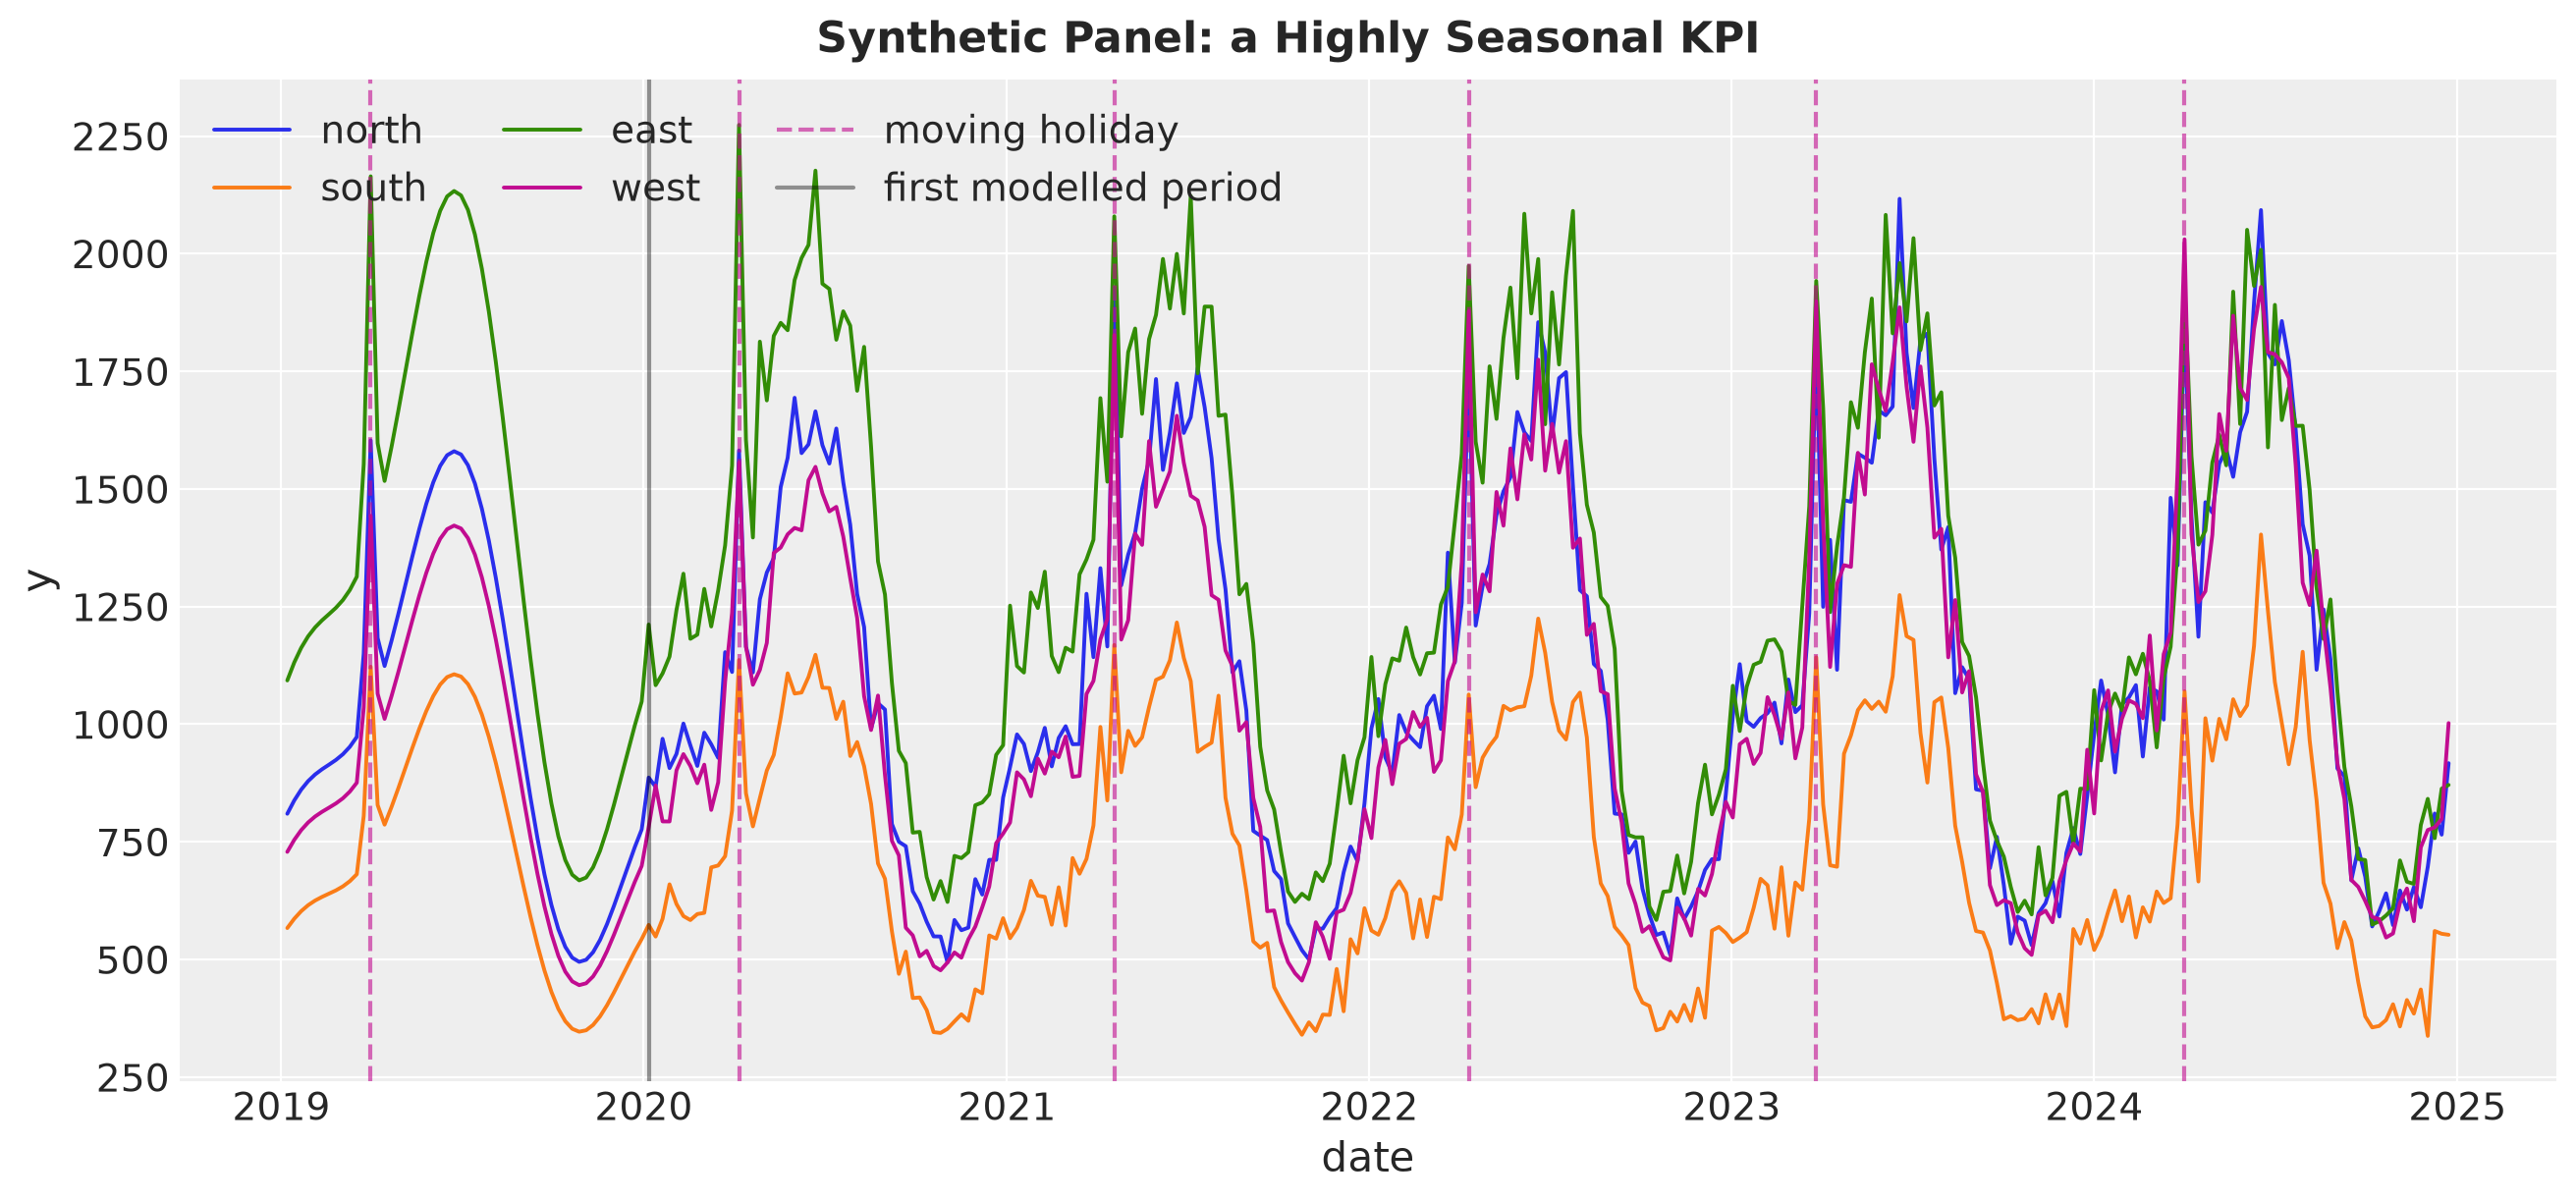

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))

for unit in unit_names:
    ax.plot(date_index, target_data.sel(unit=unit), linewidth=1.4, label=unit)

for i, t in enumerate(holiday_index):
    ax.axvline(
        date_index[t],
        color="C3",
        linestyle="--",
        alpha=0.6,
        label="moving holiday" if i == 0 else None,
    )

ax.axvline(date_index[period], color="black", alpha=0.4, label="first modelled period")
ax.legend(loc="upper left", ncol=3)
ax.set(xlabel="date", ylabel="y")
fig.suptitle("Synthetic Panel: a Highly Seasonal KPI", fontsize=16, fontweight="bold")

The seasonal amplitude is large, it grows with the level, and the holiday spike wanders between
weeks 12 and 15. Now look at the same series after the transform, with the anchored map and with
a naive 52-week lag.

Text(0.5, 0.98, 'Year-over-Year Ratio: Anchored vs Naive Reference Map')

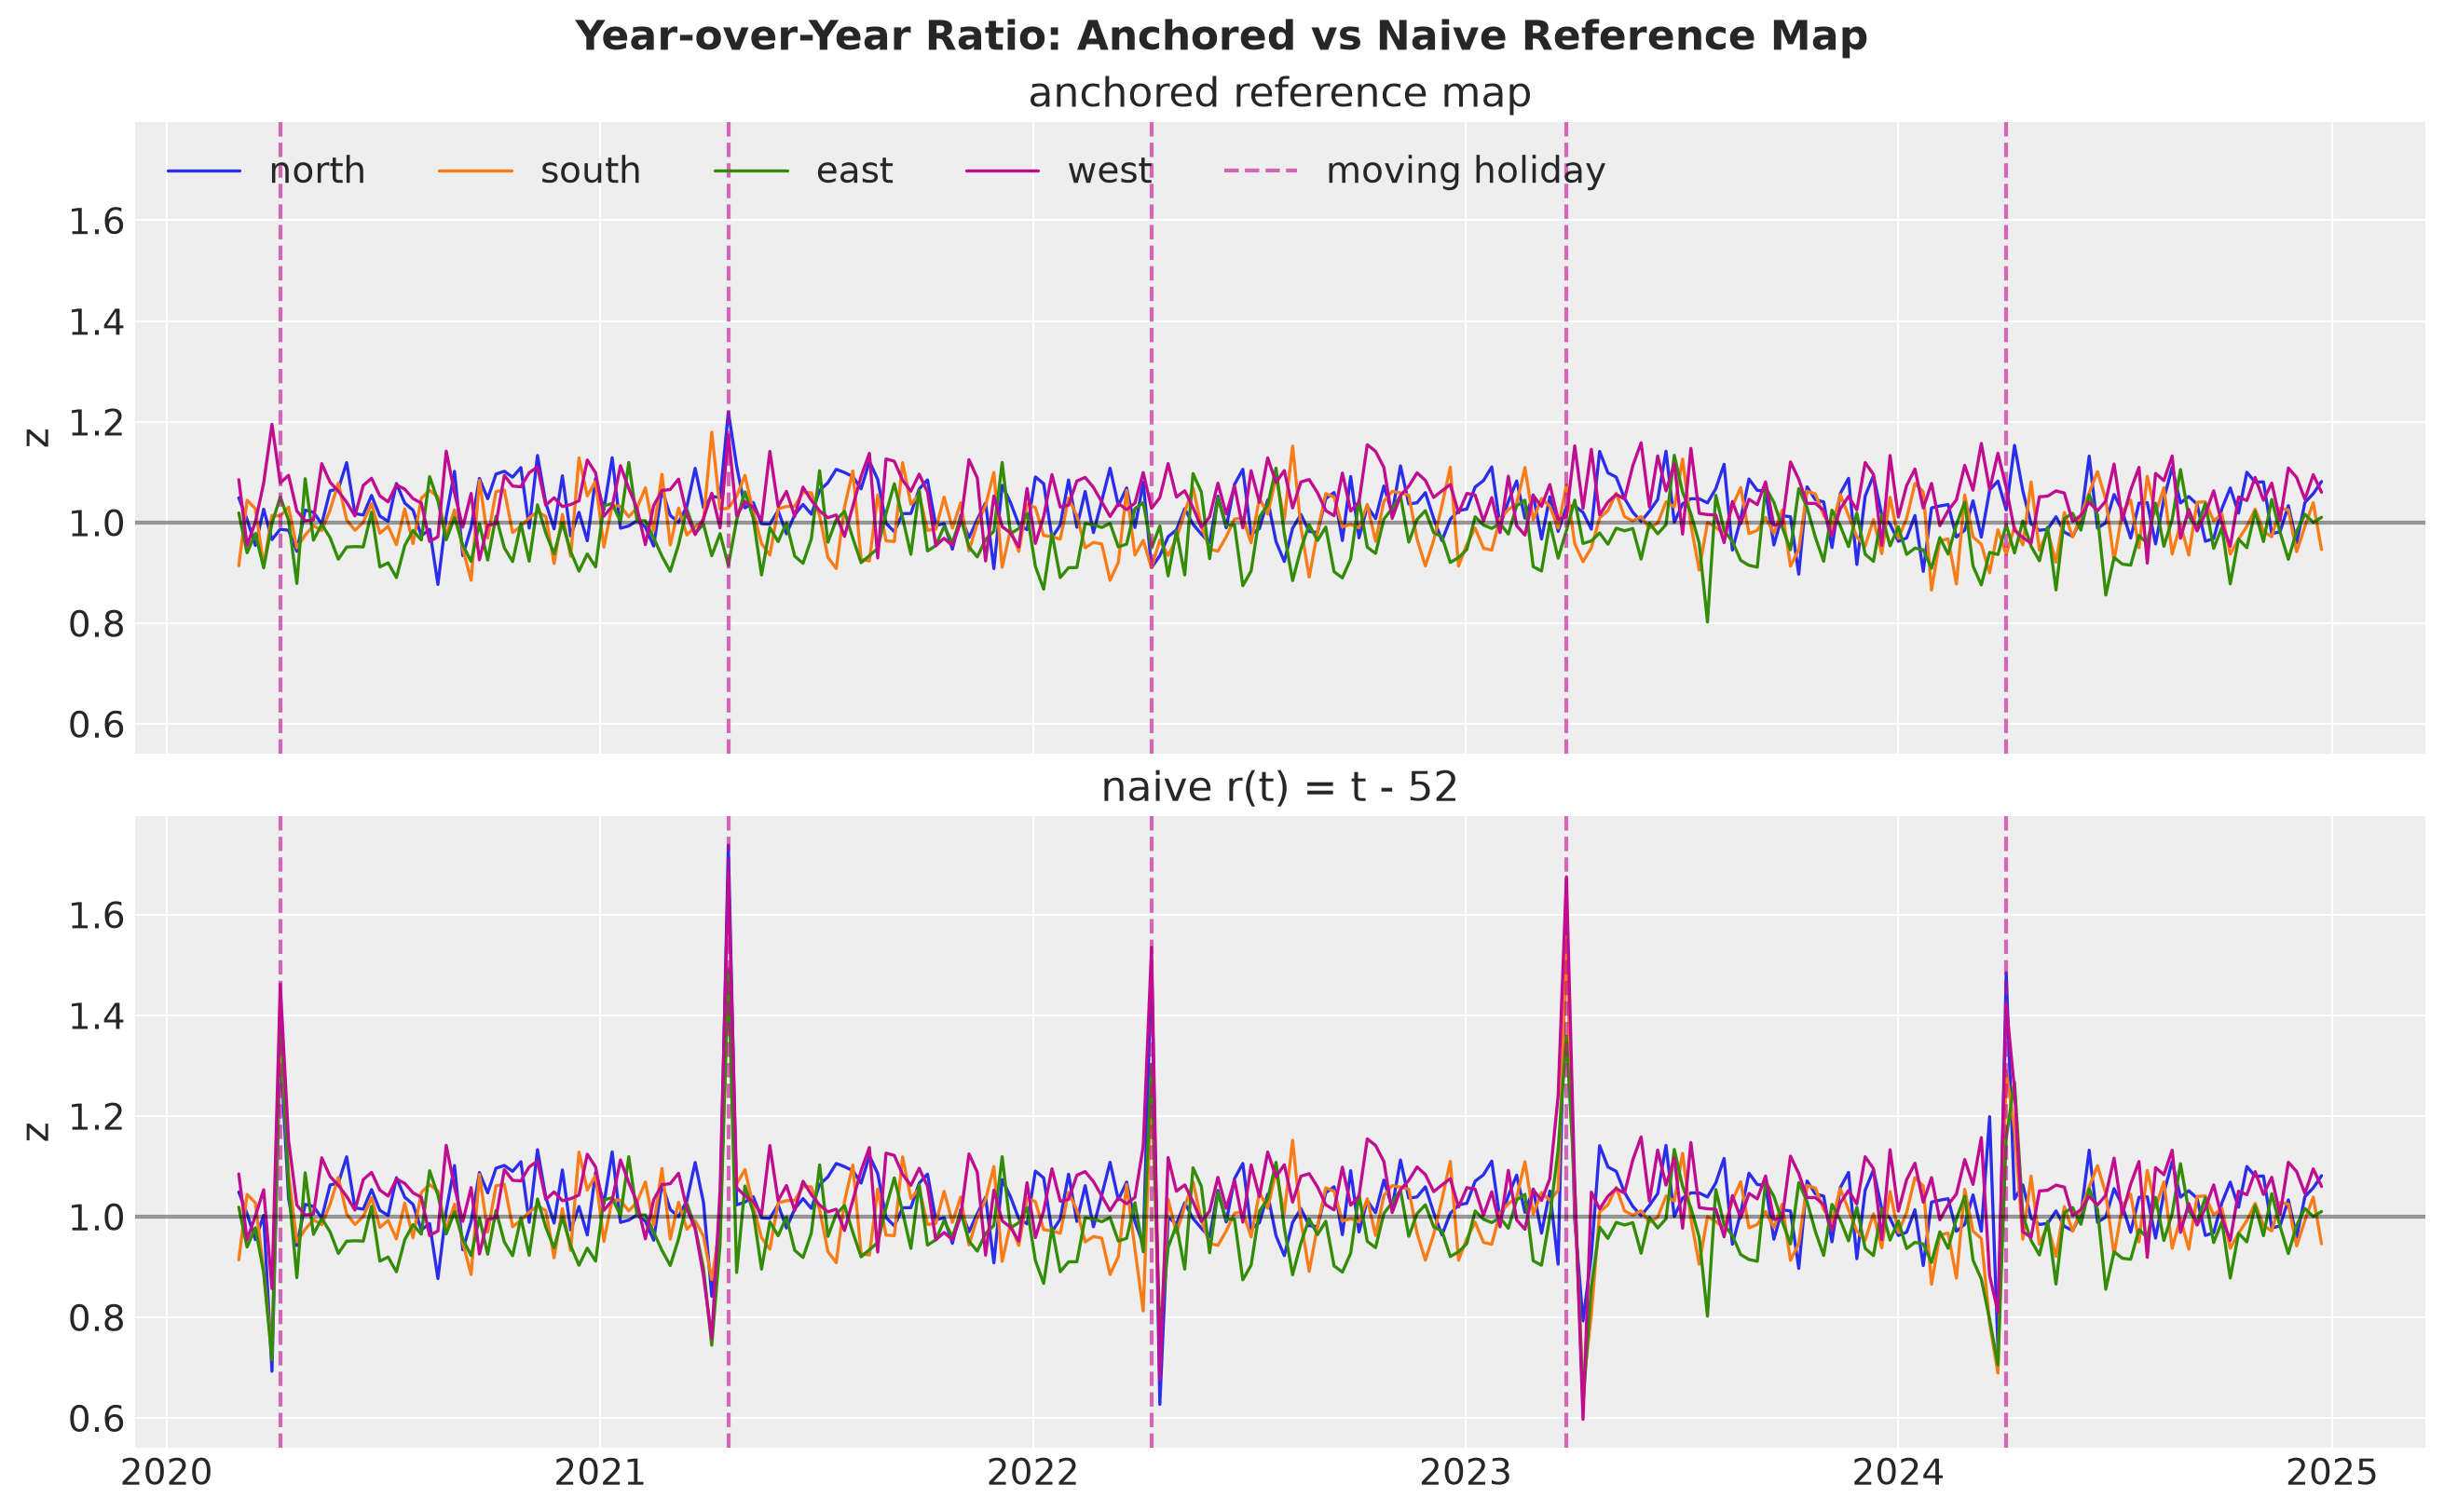

In [18]:
z_observed = xr.DataArray(
    y[obs_idx_model] / y[reference_map[obs_idx_model]],
    dims=("obs_date", "unit"),
    coords={"obs_date": date_index[obs_idx_model], "unit": unit_names},
)

z_naive = xr.DataArray(
    y[obs_idx_model] / y[naive_reference_map[obs_idx_model]],
    dims=("obs_date", "unit"),
    coords={"obs_date": date_index[obs_idx_model], "unit": unit_names},
)

fig, axes = plt.subplots(
    nrows=2, figsize=(13, 8), sharex=True, sharey=True, layout="constrained"
)

for unit in unit_names:
    axes[0].plot(
        z_observed["obs_date"], z_observed.sel(unit=unit), linewidth=1.2, label=unit
    )
    axes[1].plot(z_naive["obs_date"], z_naive.sel(unit=unit), linewidth=1.2, label=unit)

for ax, title in zip(
    axes, ["anchored reference map", "naive r(t) = t - 52"], strict=True
):
    for i, t in enumerate(holiday_index[1:]):
        ax.axvline(
            date_index[t],
            color="C3",
            linestyle="--",
            alpha=0.6,
            label="moving holiday" if i == 0 else None,
        )
    ax.axhline(1.0, color="black", alpha=0.4)
    ax.set_title(title)
    ax.set_ylabel("z")

axes[0].legend(loc="upper left", ncol=n_units + 1)
fig.suptitle(
    "Year-over-Year Ratio: Anchored vs Naive Reference Map",
    fontsize=16,
    fontweight="bold",
)

With the anchored map the ratio is a well-behaved series fluctuating around each unit's growth
rate. With the naive 52-week lag the same series carries a spike-and-crater pair at every moving
holiday, because a holiday week is being divided by a non-holiday week and vice versa. Those are
exactly the periods where the KPI is largest, so a model fitted on the naive ratio spends its
media coefficients explaining a calendar artifact.

On this panel the comparison is circular, since the levels were generated *through* the anchored
map; what it shows is the size of the artifact a wrong map produces, not evidence that this map
is right for real data.

In [19]:
naive_damage = pd.DataFrame(
    {
        "anchored": [float(z_observed.std()), float(np.abs(z_observed - 1).max())],
        "naive": [float(z_naive.std()), float(np.abs(z_naive - 1).max())],
    },
    index=["std of z", "max |z - 1|"],
)

naive_damage

,anchored,naive
std of z,0.059105,0.098595
max |z - 1|,0.219264,0.737653


## Fitting the year-over-year model

We hold out the last 52 weeks and train on everything before them. Every reference period for the
holdout window sits inside the training window, so the holdout prediction only needs observed
history, not model output.

In [20]:
n_test = period
obs_idx_train = obs_idx_model[:-n_test]
obs_idx_test = obs_idx_model[-n_test:]

train_dates = date_index[obs_idx_train]
test_dates = date_index[obs_idx_test]

print(
    f"train: {train_dates[0].date()} to {train_dates[-1].date()} ({len(obs_idx_train)} weeks)"
)
print(
    f"test:  {test_dates[0].date()} to {test_dates[-1].date()} ({len(obs_idx_test)} weeks)"
)

train: 2020-03-02 to 2023-12-25 (200 weeks)
test:  2024-01-01 to 2024-12-23 (52 weeks)


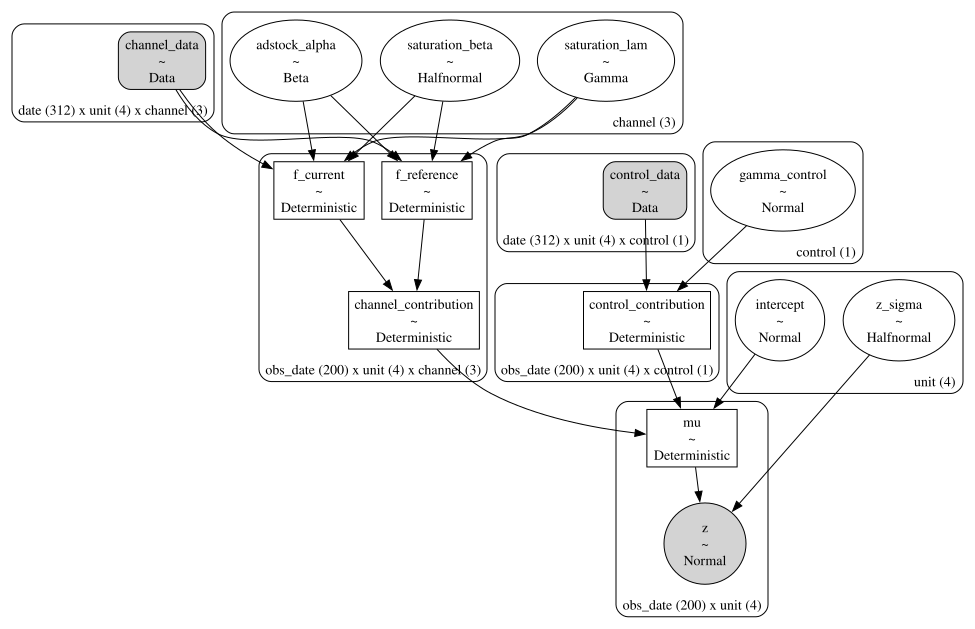

In [21]:
z_train = z_observed.isel(obs_date=slice(None, -n_test))

yoy_model = build_yoy_model(obs_idx_train, z_train)

pm.model_to_graphviz(yoy_model)

### Prior predictive check

Sampling: [adstock_alpha, gamma_control, intercept, saturation_beta, saturation_lam, z, z_sigma]


Text(0.5, 0.98, 'Prior Predictive Check (unit: north)')

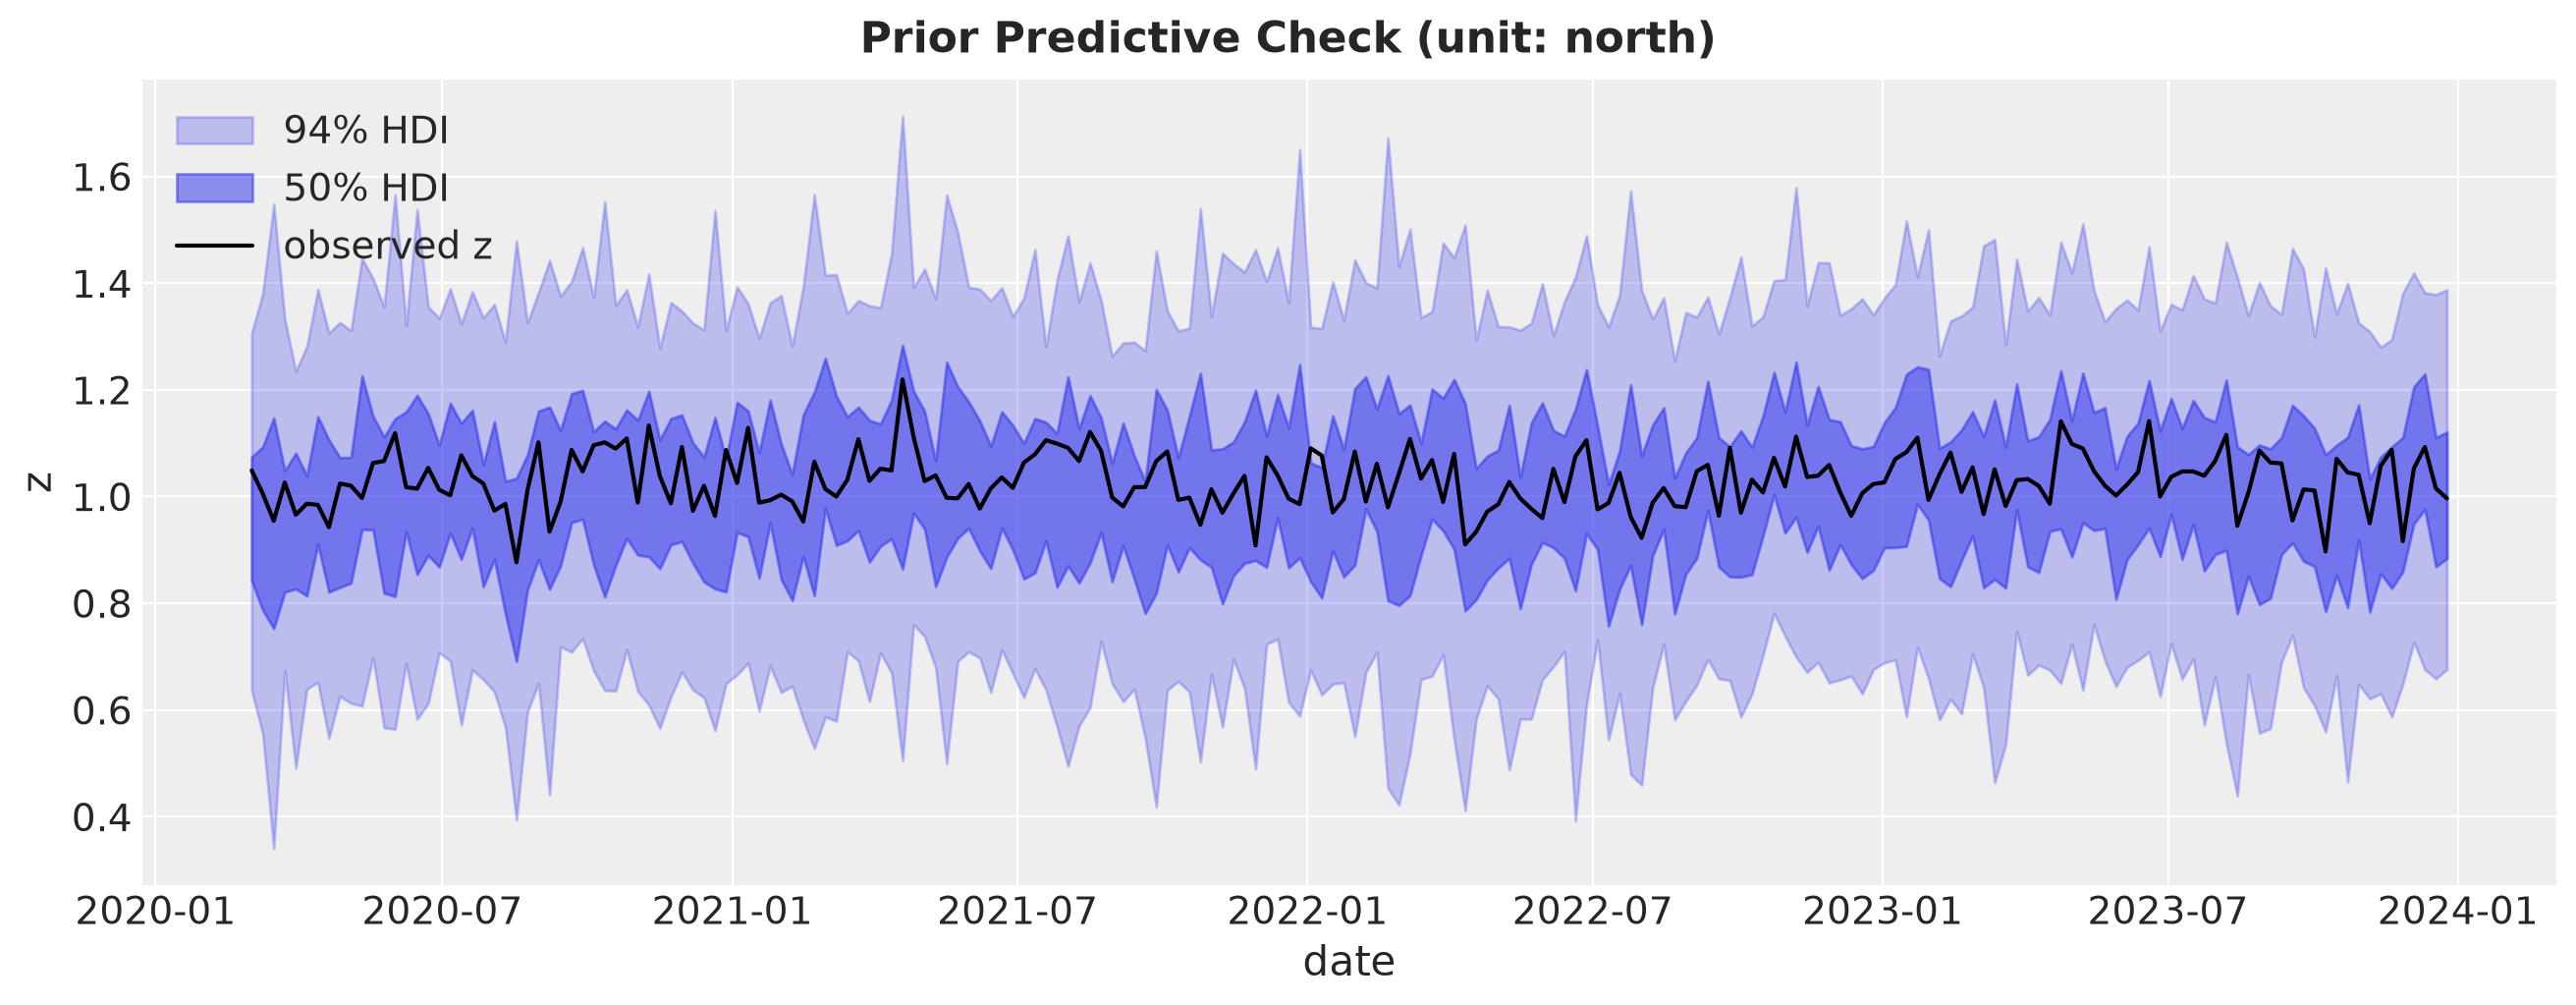

In [22]:
with yoy_model:
    yoy_prior = pm.sample_prior_predictive(draws=500, random_seed=rng)

fig, ax = plt.subplots(figsize=(13, 5))

for i, hdi_prob in enumerate([0.94, 0.5]):
    hdi = az.hdi(yoy_prior.prior_predictive["z"].sel(unit="north"), prob=hdi_prob)
    ax.fill_between(
        train_dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=0.25 + 0.25 * i,
        label=f"{hdi_prob:.0%} HDI",
    )

ax.plot(train_dates, z_train.sel(unit="north"), color="black", label="observed z")
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="z")
fig.suptitle("Prior Predictive Check (unit: north)", fontsize=16, fontweight="bold")

In [23]:
with yoy_model:
    yoy_idata = pm.sample(
        chains=4,
        tune=1_000,
        draws=1_000,
        target_accept=0.9,
        nuts_sampler="nutpie",
        random_seed=rng,
    )
    pm.sample_posterior_predictive(
        yoy_idata, random_seed=rng, extend_inferencedata=True
    )

az.summary(yoy_idata, var_names=["intercept", "gamma_control", "z_sigma"], round_to=4)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_control, intercept, z_sigma]


Output()

Sampling: [z]


Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[north],1.0297,0.0021,1.0263,1.0331,9091.8870,2887.2491,1.0017,0.0000,0.0
intercept[south],1.0022,0.0024,0.9984,1.0061,8910.9597,3057.1258,1.0021,0.0000,0.0
intercept[east],0.9760,0.0019,0.9730,0.9792,8478.2235,2818.2770,1.0019,0.0000,0.0
intercept[west],1.0488,0.0019,1.0457,1.0518,7999.9096,2812.1151,1.0015,0.0000,0.0
gamma_control[discount],0.1712,0.0054,0.1624,0.1796,7495.5540,2891.0993,1.0017,0.0001,0.0
z_sigma[north],0.0305,0.0015,0.0281,0.0330,9145.7888,3011.4740,1.0013,0.0000,0.0
z_sigma[south],0.0341,0.0017,0.0314,0.0370,9724.5205,2972.1742,1.0005,0.0000,0.0
z_sigma[east],0.0274,0.0014,0.0253,0.0296,7848.1939,2948.0659,0.9998,0.0000,0.0
z_sigma[west],0.0274,0.0014,0.0253,0.0298,7376.3155,3005.6949,1.0016,0.0000,0.0


The per-unit growth rates and the discount coefficient come back close to the truth,
`intercept = [1.03, 1.00, 0.98, 1.05]` and `gamma_control = 0.18`. The noise scales are
recovered to within the sampling variability of a 200-week sample standard deviation, which for
$\sigma \approx 0.03$ is about $0.0015$; we will need that number when reading holdout coverage.

### Parameter recovery

The data-generating process *is* this model, so the posteriors should concentrate on the true
values. Where they do not is the interesting part.

Text(0.5, 0.98, 'Parameter Recovery: Prior, Posterior, Truth')

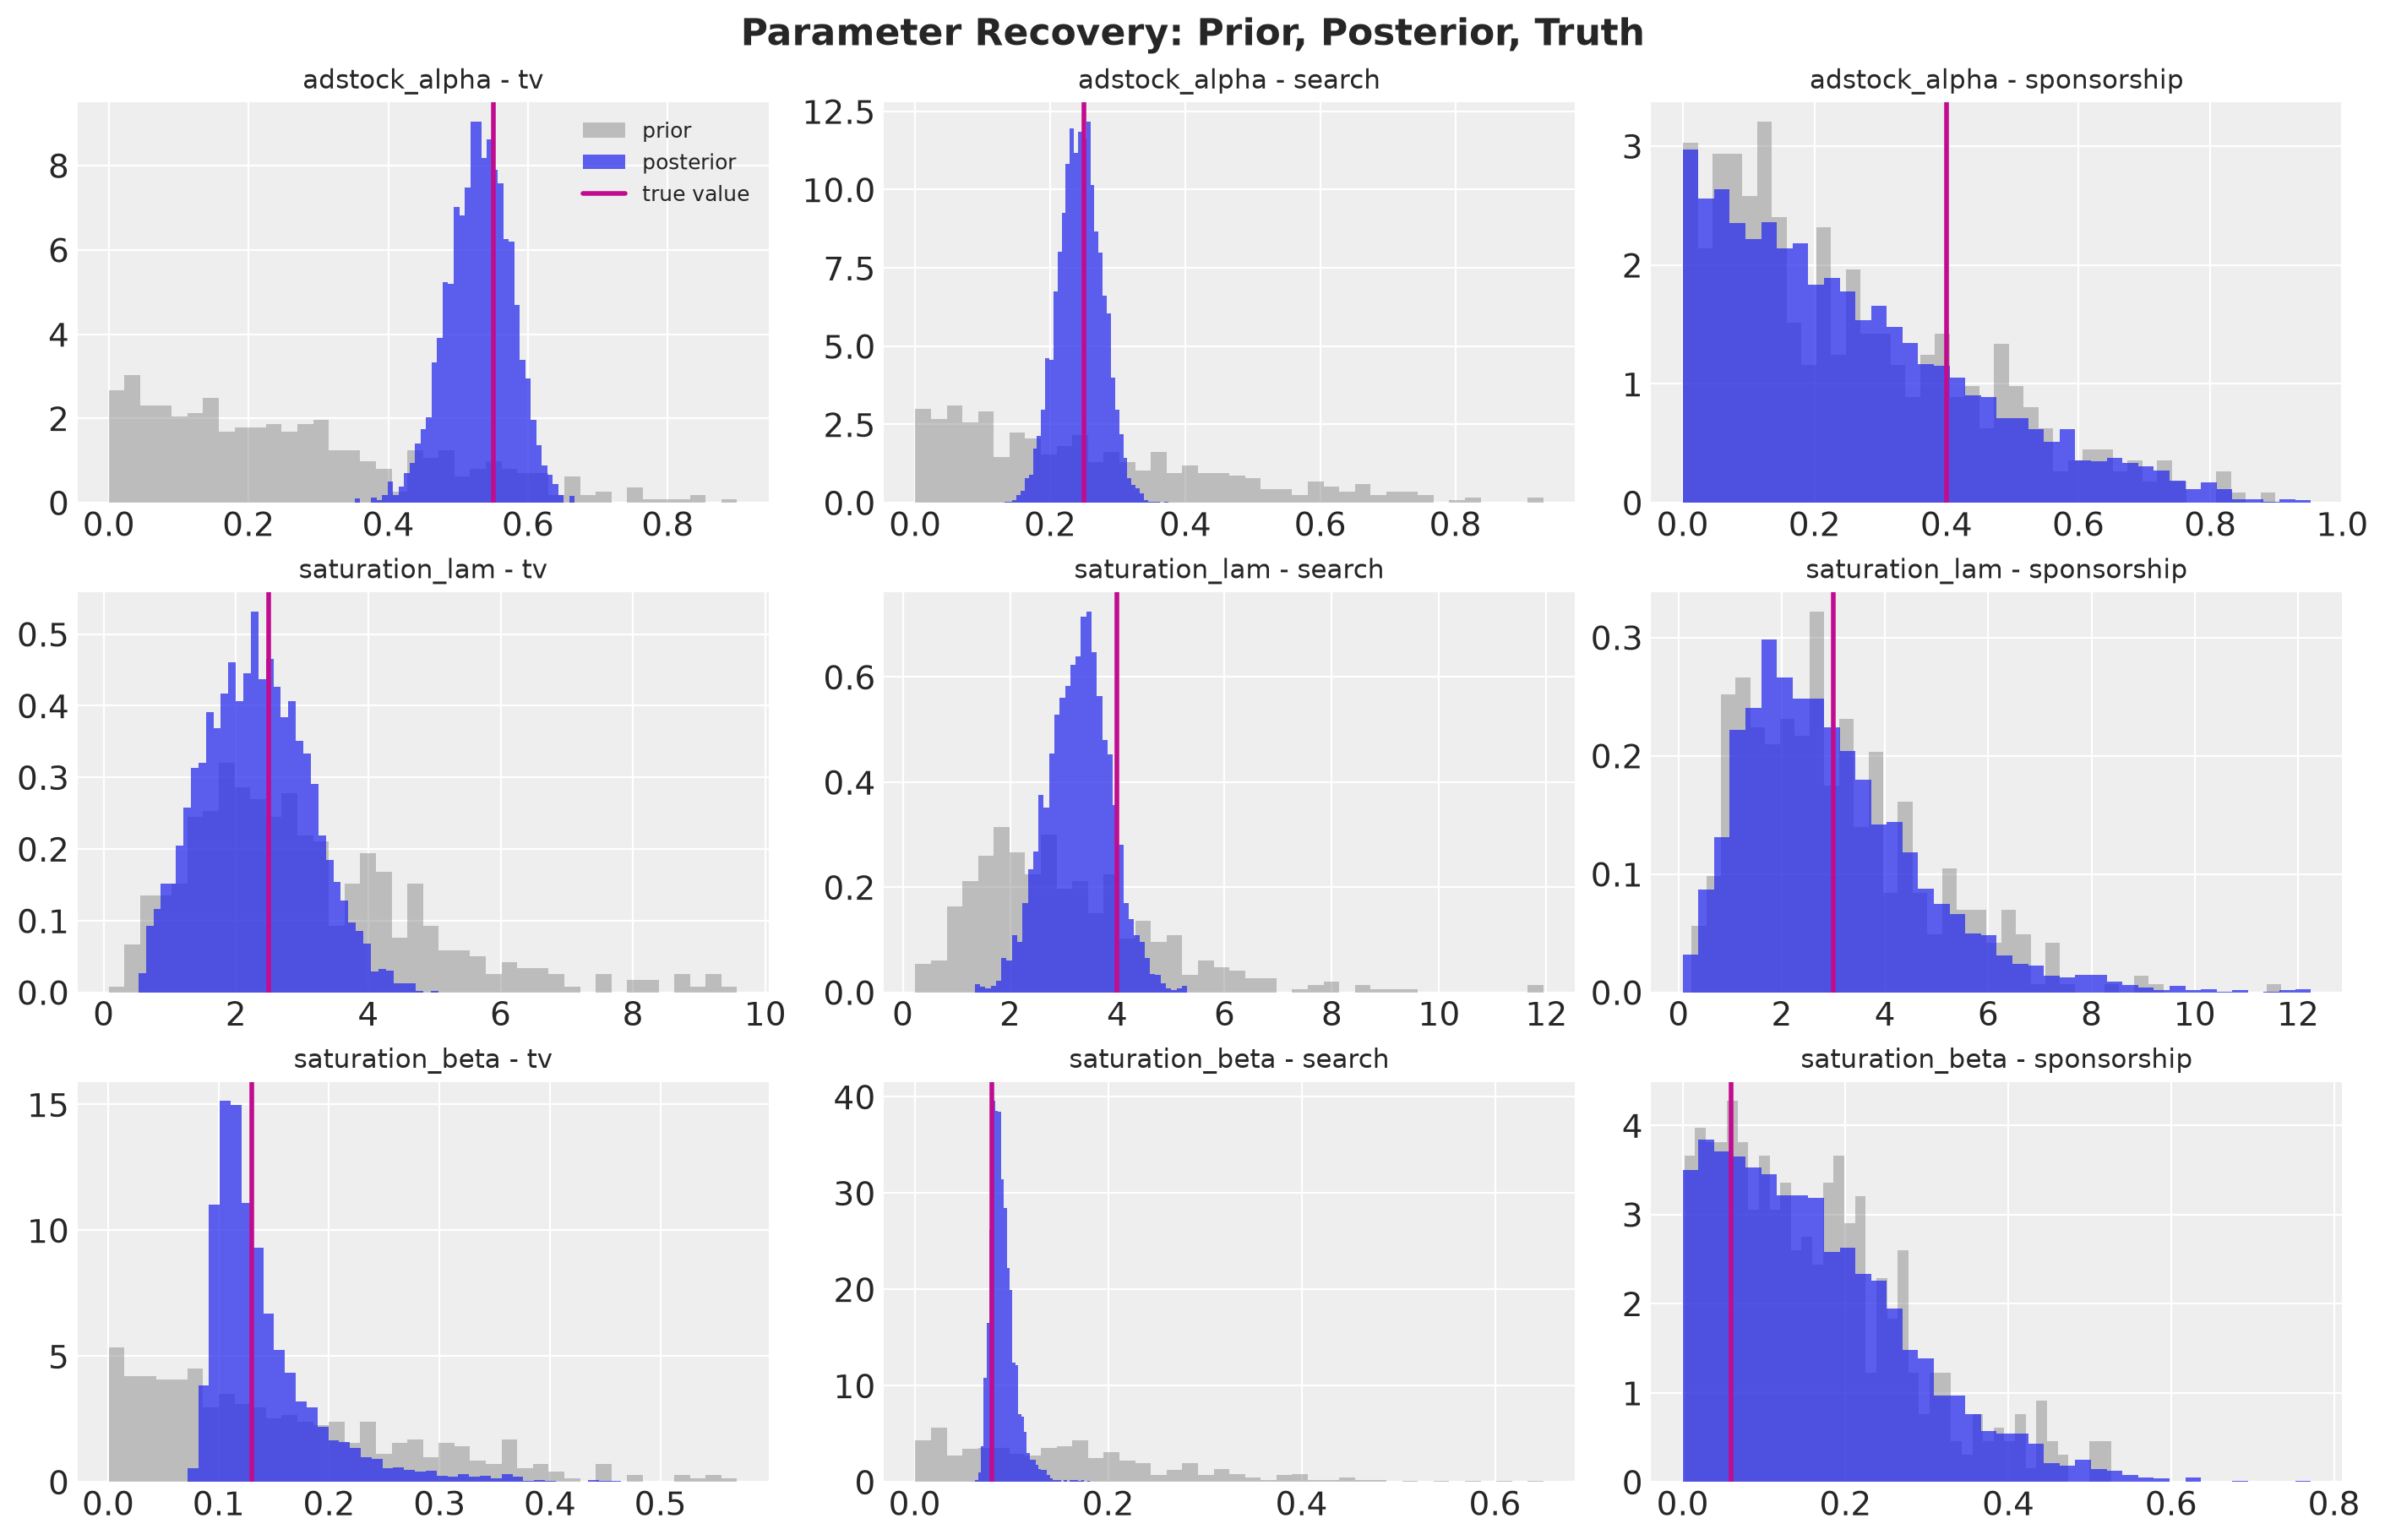

In [24]:
recovery_vars = ["adstock_alpha", "saturation_lam", "saturation_beta"]

fig, axes = plt.subplots(
    nrows=len(recovery_vars), ncols=n_channels, figsize=(14, 9), layout="constrained"
)

for row, var in enumerate(recovery_vars):
    for col, channel in enumerate(channel_columns):
        ax = axes[row, col]
        posterior_draws = (
            yoy_idata.posterior[var].sel(channel=channel).to_numpy().ravel()
        )
        prior_draws = yoy_prior.prior[var].sel(channel=channel).to_numpy().ravel()
        ax.hist(
            prior_draws, bins=40, density=True, color="grey", alpha=0.45, label="prior"
        )
        ax.hist(
            posterior_draws,
            bins=40,
            density=True,
            color="C0",
            alpha=0.75,
            label="posterior",
        )
        ax.axvline(media_truth[var][col], color="C3", linewidth=2, label="true value")
        ax.set_title(f"{var} - {channel}", fontsize=11)
        if row == 0 and col == 0:
            ax.legend(loc="upper right", fontsize=9)

fig.suptitle(
    "Parameter Recovery: Prior, Posterior, Truth", fontsize=16, fontweight="bold"
)

### The always-on channel is invisible

`tv` and `search` are recovered. `sponsorship` is not, and it never could be: its spend is
identical cycle over cycle, so $f_c(a_t) - f_c(a_{r(t)}) = 0$ for every modelled $t$, the channel
drops out of the likelihood entirely, and its posterior is its prior. (This is also why the
modelled window starts $l_{\max}$ periods after the first cycle: without the burn-in drop the
reference periods at the very start of the series carry a partially warmed adstock, and the
always-on channel leaks a small amount of spurious information.)

This is a real property of the design rather than a bug, but it is the single most dangerous thing
about the transform in practice: a user who reads a tight posterior interval on such a channel is
reading a prior and calling it evidence. We can measure it directly.

It is worth being precise about what is and is not specific to the transform here. A channel
whose spend is constant within each unit is collinear with a per-unit intercept in *any* model,
including the level-space MMM fitted below, and a plan that repeats cycle over cycle with any
shape is confounded with the seasonal basis of a level model. The transform does not create the
problem. What it does is make it exact and detectable: the contrast is identically zero, and the
prior-to-posterior ratio below says so. A level model in the same situation leans on its
seasonal basis and its intercept prior instead, and the result is a coefficient that looks
estimated but is not.

In [25]:
def prior_posterior_shift(var: str) -> pd.DataFrame:
    """Compare prior and posterior spread, one row per coordinate."""
    prior_sd = yoy_prior.prior[var].std(("chain", "draw"))
    posterior_sd = yoy_idata.posterior[var].std(("chain", "draw"))
    return pd.DataFrame(
        {
            "prior sd": prior_sd.to_series(),
            "posterior sd": posterior_sd.to_series(),
            "sd ratio": (posterior_sd / prior_sd).to_series(),
        }
    )


prior_posterior_shift("saturation_beta")

,prior sd,posterior sd,sd ratio
channel,,,
tv,0.119400,0.052157,0.436823
search,0.116234,0.013276,0.114222
sponsorship,0.115571,0.116811,1.010723


A ratio near 1 means the likelihood said nothing. `sponsorship` sits there, and no amount of data
collected under a flat plan will move it. A year-over-year target model measures **plan changes**,
not programs.

## Level-space MMMs with Fourier seasonality

For the comparison we fit standard multidimensional {class}`~pymc_marketing.mmm.mmm.MMM` models
on the same panel, in level space, with yearly Fourier seasonality and the same adstock and
saturation families. They see exactly the same training window and the same scaled spend.

We fit two of them, because the first one is a straw man and it is worth seeing by how much.

- **level + Fourier**: four yearly harmonics, the discount control, a constant per-unit intercept.
  This is the configuration a "vanilla" comparison reaches for, and it is missing two things the
  panel is known to contain: a compounding per-unit trend, and a one-off holiday that a smooth
  annual basis cannot represent.
- **level + Fourier + holiday + trend**: the same model with a linear trend control and three
  holiday indicators (week before, holiday, week after). Nothing here uses ground truth beyond
  the calendar, which a practitioner would also have.

In [26]:
holiday_dummies = {
    f"holiday_{label}": np.isin(np.arange(n_dates), np.array(holiday_index) + offset)
    for label, offset in zip(["before", "peak", "after"], holiday_offsets, strict=True)
}
level_extra_controls = ["trend", *holiday_dummies]


def make_panel_df(target: xr.DataArray) -> pd.DataFrame:
    """Long panel with scaled spend, controls, calendar features and one target column."""
    calendar_df = pd.DataFrame(
        {
            "date": date_index,
            "trend": np.arange(n_dates) / period,
            **{name: values.astype(float) for name, values in holiday_dummies.items()},
        }
    )
    return (
        channel_scaled.to_dataset(dim="channel")
        .to_dataframe()
        .reset_index()
        .merge(
            control_data.sel(control="discount", drop=True)
            .rename("discount")
            .to_dataframe()
            .reset_index(),
            on=["date", "unit"],
        )
        .merge(target.rename("y").to_dataframe().reset_index(), on=["date", "unit"])
        .merge(calendar_df, on="date")
    )


def fit_level_model(
    train_df: pd.DataFrame, controls: list[str]
) -> tuple[MMM, az.InferenceData]:
    """Fit a level-space MMM with yearly Fourier seasonality on a training panel."""
    mmm = MMM(
        date_column="date",
        channel_columns=channel_columns,
        control_columns=controls,
        target_column="y",
        adstock=GeometricAdstock(
            l_max=l_max,
            priors={"alpha": Prior("Beta", alpha=1, beta=3, dims="channel")},
        ),
        saturation=LogisticSaturation(
            priors={
                "lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
                "beta": Prior("HalfNormal", sigma=2, dims="channel"),
            }
        ),
        yearly_seasonality=4,
        dims=("unit",),
    )
    X_train = train_df.drop(columns=["y"])
    y_train = train_df["y"]
    mmm.build_model(X_train, y_train)
    # Register the target on its original scale. Without this the posterior predictive comes back
    # in the internally scaled space and is not comparable with the year-over-year predictions.
    mmm.add_original_scale_contribution_variable(var=["y"])
    idata = mmm.fit(
        X_train,
        y_train,
        chains=4,
        tune=1_000,
        draws=1_000,
        target_accept=0.95,
        nuts_sampler="nutpie",
        random_seed=rng,
    )
    return mmm, idata


def predict_level_model(mmm: MMM, test_df: pd.DataFrame) -> xr.DataArray:
    """Posterior predictive of a level-space MMM on the holdout, in KPI units."""
    pp = mmm.sample_posterior_predictive(
        X=test_df.drop(columns=["y"]),
        extend_idata=False,
        combined=False,
        include_last_observations=True,
        var_names=["y", "y_original_scale"],
        random_seed=rng,
    )
    return pp["y_original_scale"]


def convergence(mmm: MMM, idata: az.InferenceData) -> pd.Series:
    """Sampler diagnostics over the free parameters, split by the identification ridge."""
    summary = az.summary(idata, var_names=[rv.name for rv in mmm.model.free_RVs])
    on_ridge = summary.index.str.startswith(
        "intercept_contribution"
    ) | summary.index.str.contains("sponsorship")
    return pd.Series(
        {
            "min ess_bulk, intercept and sponsorship": summary.loc[
                on_ridge, "ess_bulk"
            ].min(),
            "max r_hat, intercept and sponsorship": summary.loc[
                on_ridge, "r_hat"
            ].max(),
            "min ess_bulk, all other parameters": summary.loc[
                ~on_ridge, "ess_bulk"
            ].min(),
            "max r_hat, all other parameters": summary.loc[~on_ridge, "r_hat"].max(),
            "divergences": int(idata.sample_stats["diverging"].sum()),
        }
    )

In [27]:
panel_df = make_panel_df(target_data)
train_df = panel_df[panel_df["date"].isin(train_dates)].reset_index(drop=True)
test_df = panel_df[panel_df["date"].isin(test_dates)].reset_index(drop=True)

level_mmm, level_idata = fit_level_model(train_df, controls=["discount"])
level_full_mmm, level_full_idata = fit_level_model(
    train_df, controls=["discount", *level_extra_controls]
)

pd.DataFrame(
    {
        "level + Fourier": convergence(level_mmm, level_idata),
        "level + Fourier + holiday + trend": convergence(
            level_full_mmm, level_full_idata
        ),
    }
)

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

,level + Fourier,level + Fourier + holiday + trend
"min ess_bulk, intercept and sponsorship",10,7
"max r_hat, intercept and sponsorship",1.32,1.51
"min ess_bulk, all other parameters",304,326
"max r_hat, all other parameters",1.02,1.01
divergences,5,18


```{warning}
Both level models have one part of the posterior that does not converge, and it is the same part:
the per-unit intercepts and the `sponsorship` saturation parameters. Everything else samples
cleanly. That ridge is the collinearity described above, seen from the level model's side: a
channel that is constant within each unit is indistinguishable from the per-unit intercept, so the
data leave a two-dimensional family of parameter values that fit equally well, and the sampler
wanders along it. It is the level-space face of the ratio model's `sd ratio = 1`, with the
difference that the ratio model reports it as a clean number and the level model reports it as a
sampling pathology. The ridge is invariant for prediction, since `intercept + beta * f(constant)`
is what the data pin down; the per-chain holdout errors in the next section confirm that. More
draws would not change what the data can identify.
```

In [28]:
az.summary(
    level_full_idata,
    var_names=["adstock_alpha", "saturation_lam", "y_sigma"],
    round_to=4,
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
adstock_alpha[tv],0.3997,0.1429,0.1467,0.6141,1808.1673,1129.6870,1.0008,0.0035,0.0023
adstock_alpha[search],0.1106,0.0758,0.0133,0.2507,2943.6599,1699.9208,1.0007,0.0012,0.0009
adstock_alpha[sponsorship],0.0904,0.1134,0.0031,0.3176,21.7251,85.9875,1.1263,0.0194,0.0283
saturation_lam[tv],1.6463,1.0328,0.3397,3.4753,339.0179,341.6949,1.0055,0.0481,0.0427
saturation_lam[search],1.8398,1.0141,0.4301,3.6563,434.5524,358.0582,1.0071,0.0441,0.0319
saturation_lam[sponsorship],2.8736,2.2202,0.3211,6.9305,19.7240,34.0771,1.1753,0.4625,0.4716
y_sigma[east],0.0349,0.0019,0.0321,0.0380,4207.2908,2413.1728,1.0009,0.0000,0.0000
y_sigma[north],0.0296,0.0016,0.0272,0.0322,4680.2758,2575.9685,1.0019,0.0000,0.0000
y_sigma[south],0.0219,0.0012,0.0201,0.0239,5707.0089,2713.6596,1.0004,0.0000,0.0000
y_sigma[west],0.0268,0.0014,0.0247,0.0291,5298.8404,3034.6225,1.0015,0.0000,0.0000


```{note}
The `saturation_beta` values of the two model families are not comparable: one is in ratio points
and the other in KPI units. `adstock_alpha` is scale free, and all models see the same scaled
spend, so that one is.
```

## Out-of-sample comparison

All models now predict the last 52 weeks in **KPI units**, which is the only scale on which they
are comparable.

- The year-over-year model predicts $z$ on the holdout window and multiplies by the observed
  reference level $y_{u,r(t)}$, which for this window sits entirely inside the training data.
- The level models predict $y$ directly, with `include_last_observations=True` so that their
  adstock carries over from the training window.

A holdout table with two rows invites the wrong reading, so we add the rows that locate the gain.

- **Noise floor**: the true $\mu$ times the reference level. No model can do better than this in
  expectation, and the size of the gap between it and the year-over-year row is the size of the
  estimation error.
- **Seasonal naive**: $\hat y_{u,t} = y_{u,r(t)}$ (zero parameters) and
  $\hat y_{u,t} = \bar z_u\, y_{u,r(t)}$ with $\bar z_u$ the training mean ratio (four parameters,
  no media, no controls). Anything the year-over-year model gains beyond this row is what media
  and the control are buying; anything the level models lose against it is what a level-space
  seasonal basis costs on this panel.

In [29]:
def forecast_yoy(idata: az.InferenceData, levels: np.ndarray) -> xr.DataArray:
    """Posterior predictive of the ratio model on the holdout, in KPI units."""
    predict_model = build_yoy_model(obs_idx_test)
    # Only the free parameters travel to the prediction model: the stored deterministics are
    # shaped for the training window and would clash with the 52-week prediction window.
    free_names = [rv.name for rv in predict_model.free_RVs]
    posterior_free = idata.posterior.to_dataset()[free_names]
    with predict_model:
        forecast = pm.sample_posterior_predictive(
            posterior_free, var_names=["z"], random_seed=rng, predictions=True
        )
    reference = xr.DataArray(
        levels[reference_map[obs_idx_test]],
        dims=("obs_date", "unit"),
        coords={"obs_date": test_dates, "unit": unit_names},
    )
    return (forecast.predictions["z"] * reference).rename({"obs_date": "date"})


def seasonal_naive(levels: np.ndarray, growth: np.ndarray) -> xr.DataArray:
    """Forecast the holdout as the reference level times a per-unit growth factor."""
    return xr.DataArray(
        levels[reference_map[obs_idx_test]] * growth[None, :],
        dims=("date", "unit"),
        coords={"date": test_dates, "unit": unit_names},
    )


def score(pred: xr.DataArray, actual: xr.DataArray, name: str) -> pd.Series:
    """Point and interval scores in KPI units; interval scores need chain and draw dims."""
    is_holiday = xr.DataArray(
        np.isin(obs_idx_test, holiday_weeks), dims="date", coords={"date": test_dates}
    )
    if "draw" in pred.dims:
        mean = pred.mean(("chain", "draw"))
        hdi = az.hdi(pred, prob=0.94)
        lower, upper = hdi.sel(ci_bound="lower"), hdi.sel(ci_bound="upper")
        coverage = float(((actual >= lower) & (actual <= upper)).mean())
        width = float((upper - lower).mean())
    else:
        mean, coverage, width = pred, np.nan, np.nan
    error = mean - actual
    return pd.Series(
        {
            "RMSE": float(np.sqrt((error**2).mean())),
            "MAPE (%)": float((np.abs(error) / actual).mean() * 100),
            "MSE share in holiday window": float(
                (error**2).where(is_holiday).sum() / (error**2).sum()
            ),
            "94% coverage": coverage,
            "mean 94% HDI width": width,
        },
        name=name,
    )

In [30]:
y_test = target_data.sel(date=test_dates)
y_reference_test = y[reference_map[obs_idx_test]]

yoy_pred = forecast_yoy(yoy_idata, levels=y)
level_pred = predict_level_model(level_mmm, test_df)
level_full_pred = predict_level_model(level_full_mmm, test_df)

noise_floor_pred = xr.DataArray(
    mu_true.sel(obs_date=test_dates).to_numpy() * y_reference_test,
    dims=("date", "unit"),
    coords={"date": test_dates, "unit": unit_names},
)
growth_hat = z_train.mean("obs_date").to_numpy()

comparison = pd.concat(
    [
        score(noise_floor_pred, y_test, "noise floor (true mu)"),
        score(yoy_pred, y_test, "year-over-year"),
        score(seasonal_naive(y, growth_hat), y_test, "seasonal naive, fitted growth"),
        score(seasonal_naive(y, np.ones(n_units)), y_test, "seasonal naive, z = 1"),
        score(level_full_pred, y_test, "level + Fourier + holiday + trend"),
        score(level_pred, y_test, "level + Fourier"),
    ],
    axis=1,
)

comparison

Sampling: [z]


Output()

Sampling: [y]


Output()

Sampling: [y]


Output()

,noise floor (true mu),year-over-year,"seasonal naive, fitted growth","seasonal naive, z = 1",level + Fourier + holiday + trend,level + Fourier
RMSE,36.466239,37.053259,59.613288,69.265972,88.339219,145.810265
MAPE (%),2.549139,2.590879,4.205532,4.777937,6.573630,9.293397
MSE share in holiday window,0.074251,0.071813,0.092350,0.126049,0.060793,0.331799
94% coverage,NaN,0.899038,NaN,NaN,0.860577,0.884615
mean 94% HDI width,NaN,116.975472,NaN,NaN,252.429288,394.749421


Read the table top down.

1. The year-over-year model sits within a few percent of the noise floor on RMSE and MAPE. On
   this panel it cannot be beaten, and the headline number is the noise level of the data, not a
   measure of the model.
2. The seasonal-naive rows are the ones to compare the level models against. A four-parameter
   growth-times-last-year forecast with no media in it beats both level models, the plain one by
   a wide margin. Most of the gap between the two families is the reference level, not the MMM;
   media and the control account for the remaining distance from the naive row down to the
   year-over-year row.
3. The plain level model's error is concentrated where its specification is wrong. A third of
   its squared error sits in the three holiday weeks, and the rest is dominated by per-unit bias
   with the sign of each unit's growth rate, because a constant intercept cannot extrapolate a
   compounding trend. Adding the trend and the holiday indicators removes most of both, and the
   remaining gap to the naive row is what a smooth seasonal basis pays against a seasonal random
   walk: the level model estimates one shape from four noisy years, while the ratio model
   conditions on last year's realisation of it.

Before trusting the level rows, check that the unconverged ridge did not leak into them. If the
chains disagreed about anything that matters for prediction, their holdout errors would differ.

In [31]:
def rmse_by_chain(pred: xr.DataArray, actual: xr.DataArray) -> pd.Series:
    """Holdout RMSE of each chain's posterior-mean forecast."""
    error = pred.mean("draw") - actual
    return np.sqrt((error**2).mean(("date", "unit"))).to_series()


pd.DataFrame(
    {
        "year-over-year": rmse_by_chain(yoy_pred, y_test),
        "level + Fourier + holiday + trend": rmse_by_chain(level_full_pred, y_test),
        "level + Fourier": rmse_by_chain(level_pred, y_test),
    }
)

,year-over-year,level + Fourier + holiday + trend,level + Fourier
chain,,,
0,37.010233,88.395500,145.598432
1,37.001662,88.330973,145.959020
2,37.163574,88.329718,146.147624
3,37.084871,88.379356,145.643705


Text(0.5, 0.98, 'Holdout Forecast, Last 52 Weeks')

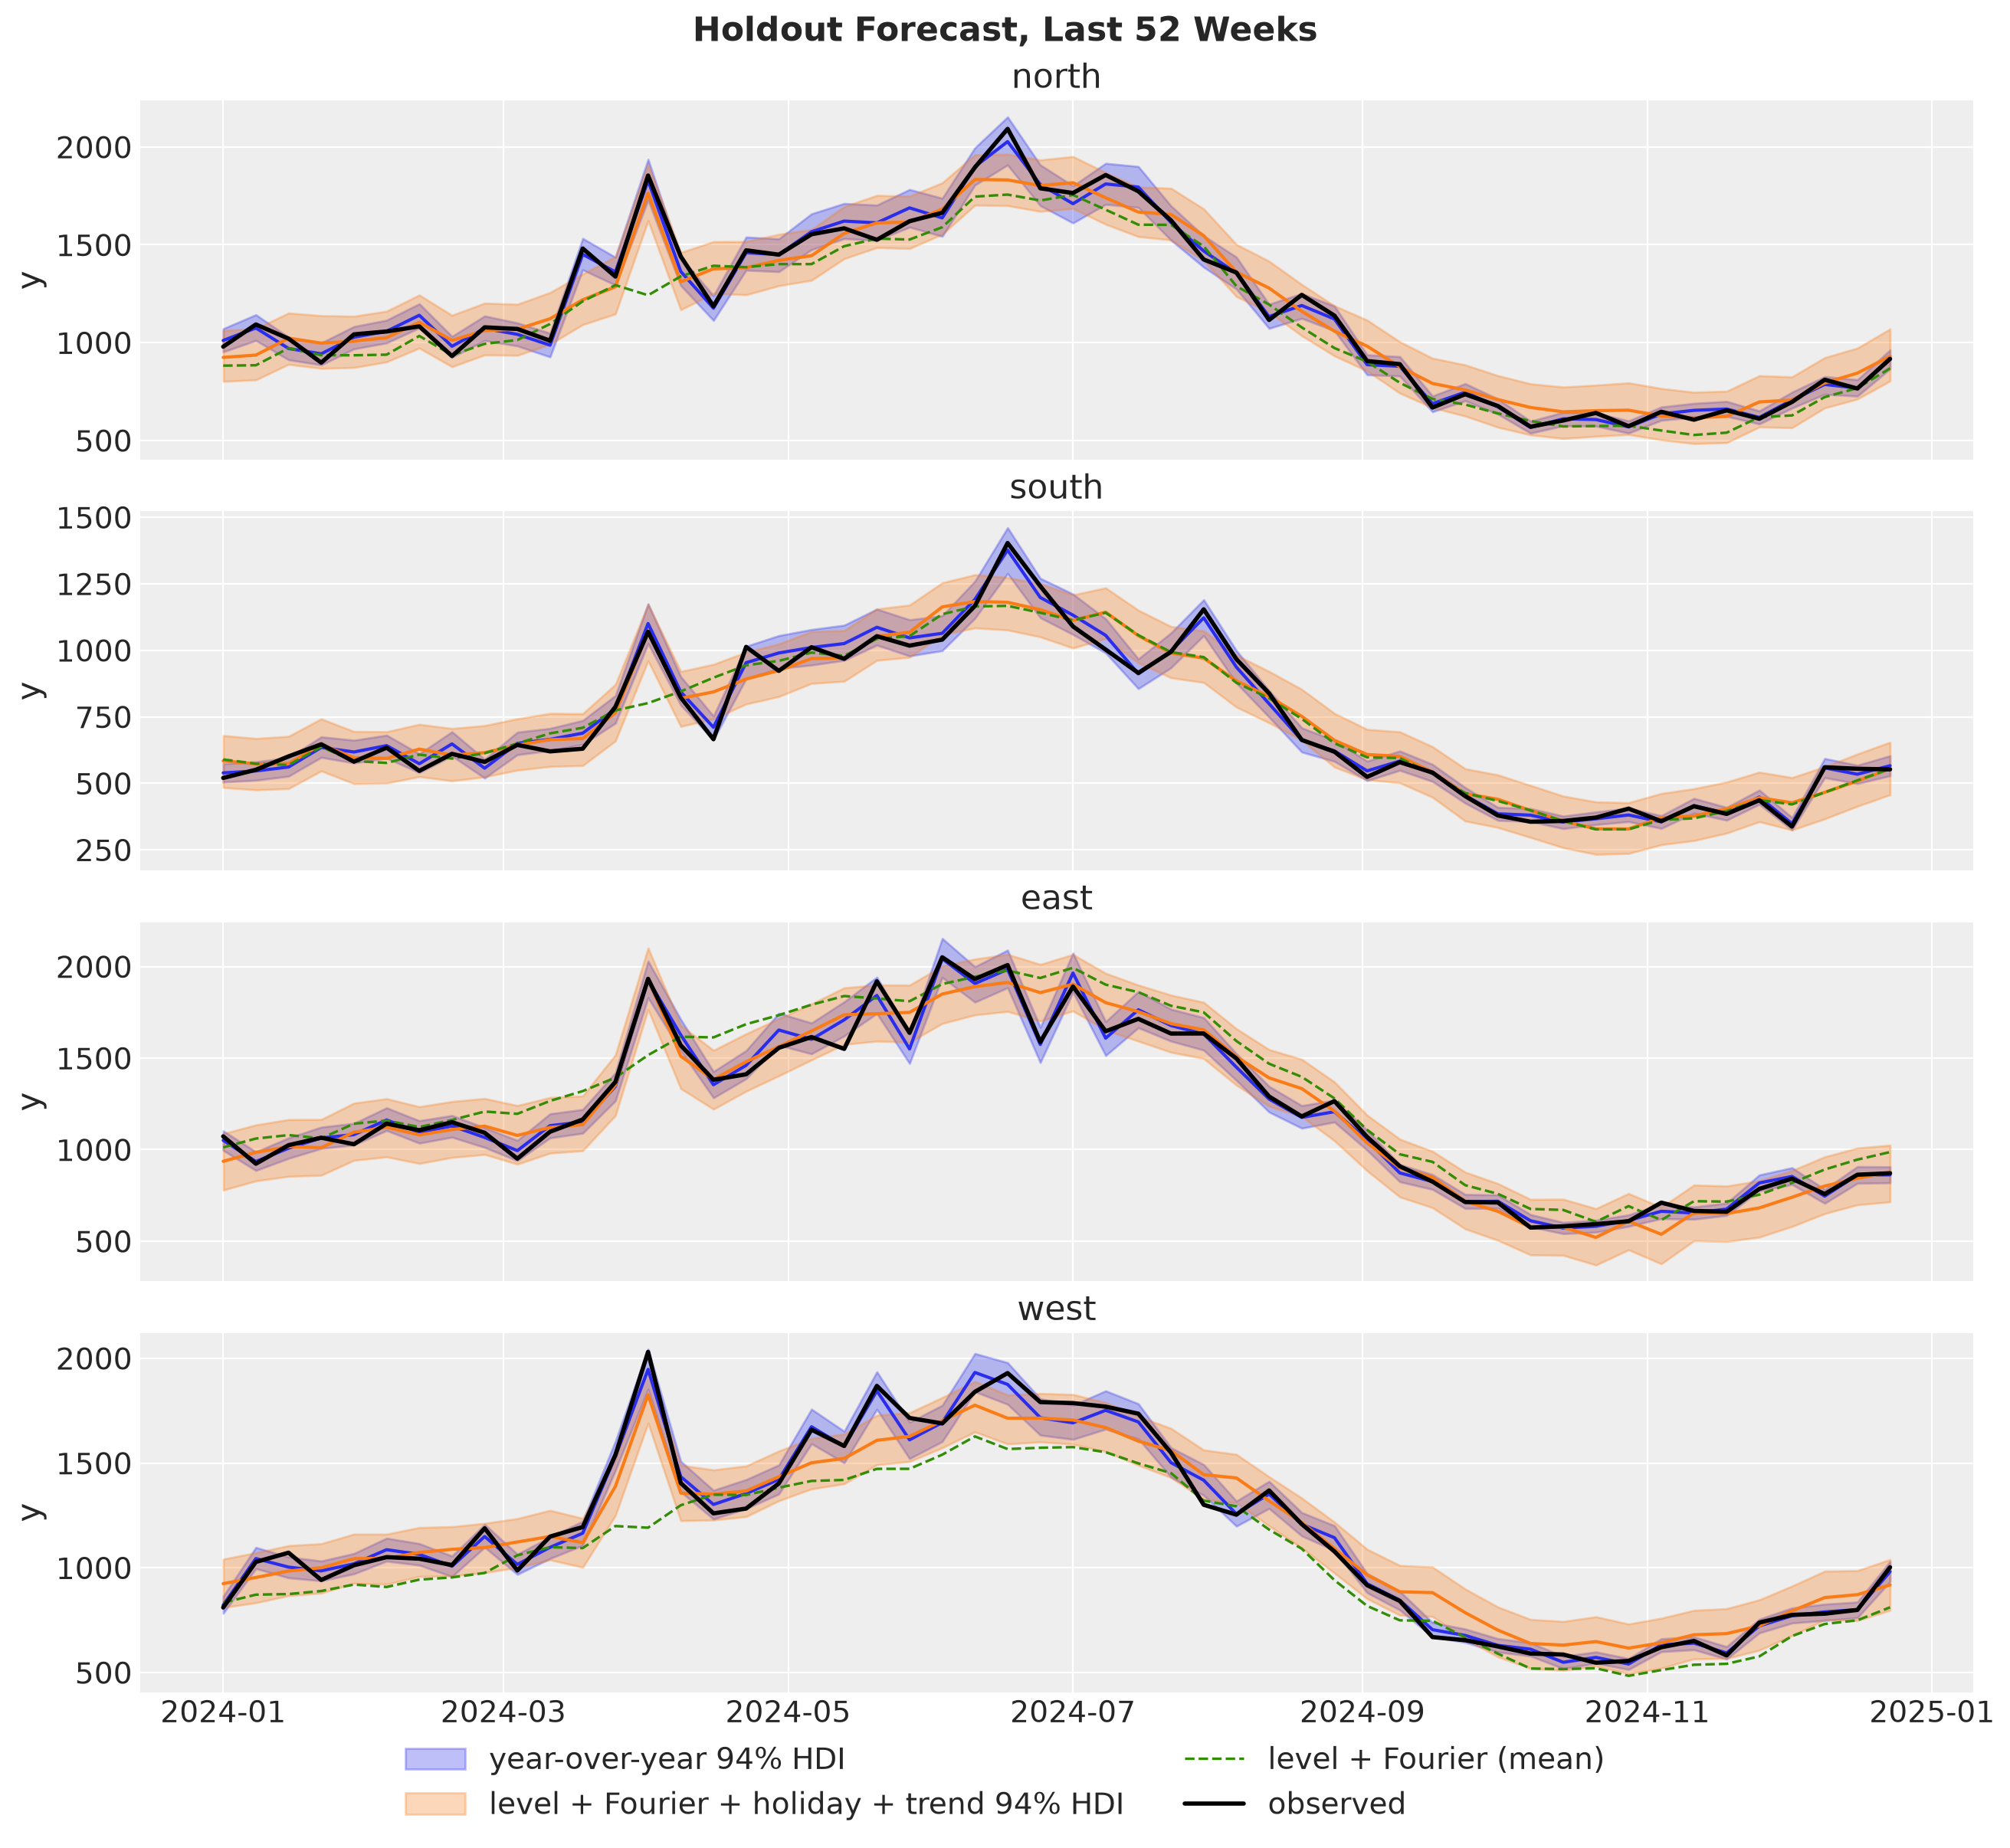

In [32]:
fig, axes = plt.subplots(
    nrows=n_units, figsize=(13, 3.0 * n_units), sharex=True, layout="constrained"
)

for ax, unit in zip(axes, unit_names, strict=True):
    for pred, color, label in [
        (yoy_pred, "C0", "year-over-year"),
        (level_full_pred, "C1", "level + Fourier + holiday + trend"),
    ]:
        hdi = az.hdi(pred.sel(unit=unit), prob=0.94)
        ax.fill_between(
            test_dates,
            hdi.sel(ci_bound="lower"),
            hdi.sel(ci_bound="upper"),
            color=color,
            alpha=0.3,
            label=f"{label} 94% HDI",
        )
        ax.plot(
            test_dates,
            pred.sel(unit=unit).mean(("chain", "draw")),
            color=color,
            linewidth=1.5,
        )
    ax.plot(
        test_dates,
        level_pred.sel(unit=unit).mean(("chain", "draw")),
        color="C2",
        linewidth=1.2,
        linestyle="--",
        label="level + Fourier (mean)",
    )
    ax.plot(
        test_dates, y_test.sel(unit=unit), color="black", linewidth=2, label="observed"
    )
    ax.set_title(unit)
    ax.set_ylabel("y")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=2)
fig.suptitle("Holdout Forecast, Last 52 Weeks", fontsize=16, fontweight="bold")

### Reading coverage

Coverage has to be read together with interval width. The level models' intervals are two to
three times wider than the ratio model's and still fall short of nominal coverage, partly because
a single residual scale per unit has to cover the seasonal peak everywhere, and mostly because
the misfit of the mean has been absorbed into `y_sigma`, which widens the intervals without
centring them. The ratio model's intervals are rescaled by $y_{u,r(t)}$ and track the cycle.

The ratio model's coverage lands a little below nominal. Under this data-generating process the
proportional noise model is exactly right, so there is no structural reason for that; the
explanation is in the per-unit numbers. Each `z_sigma` is estimated from 200 training weeks, and
the realised noise in the 52 holdout weeks need not match it.

In [33]:
yoy_hdi = az.hdi(yoy_pred, prob=0.94)
covered = (y_test >= yoy_hdi.sel(ci_bound="lower")) & (
    y_test <= yoy_hdi.sel(ci_bound="upper")
)
noise_realised = (z_observed - mu_true.sel(obs_date=z_observed["obs_date"])).to_numpy()

coverage_by_unit = pd.DataFrame(
    {
        "true z_sigma": z_sigma_true,
        "posterior z_sigma": yoy_idata.posterior["z_sigma"].mean(("chain", "draw")),
        "realised noise sd, train": noise_realised[:-n_test].std(axis=0, ddof=1),
        "realised noise sd, test": noise_realised[-n_test:].std(axis=0, ddof=1),
        "94% coverage, test": covered.mean("date"),
    },
    index=pd.Index(unit_names, name="unit"),
)

coverage_by_unit

,true z_sigma,posterior z_sigma,"realised noise sd, train","realised noise sd, test","94% coverage, test"
unit,,,,,
north,0.030,0.030486,0.030295,0.028756,0.961538
south,0.035,0.034131,0.033734,0.036426,0.903846
east,0.028,0.027404,0.027100,0.029397,0.903846
west,0.032,0.027397,0.027389,0.034652,0.826923


The posterior `z_sigma` tracks the *realised* training noise rather than the true value, as it
should, and the unit with the lowest coverage is the one whose holdout weeks happened to be
noisier than its training weeks. For that unit the intervals are about a fifth too narrow, and a
94% interval that is a fifth too narrow covers about 86% of the time, which is what we see. This
is one unlucky draw of 52 weeks, not a defect of the noise model, and nothing in this table would
move a practitioner to change it.

## Contributions: two questions, two answers

Contributions have to be converted to KPI units **per unit-period**, by multiplying each
ratio-space part by that unit-period's own $y_{u,r(t)}$, and only then summed. Averaging ratio
contributions across a panel and scaling the average by a single reference factor is a different
number, and the discrepancy grows with dispersion in unit size.

The closure check below asserts that the dollarised parts plus the dollarised residual reproduce
the **observed level** $y_{u,t}$ at every unit-period. That is a check on the dollarisation: it
fails if the reference level used to convert the parts is not the one that defined $z$, or if
the parts were aggregated before conversion. It is not a check on how $\mu$ was split into
parts; any split that sums to $\mu$ passes, so a constant moved between the baseline and a
control would not be caught here. The split is a modelling decision, and the next section is
about making it explicit.

In [34]:
posterior = yoy_idata.posterior.to_dataset()

y_reference_train = xr.DataArray(
    y[reference_map[obs_idx_train]],
    dims=("obs_date", "unit"),
    coords={"obs_date": train_dates, "unit": unit_names},
)
y_observed_train = xr.DataArray(
    y[obs_idx_train],
    dims=("obs_date", "unit"),
    coords={"obs_date": train_dates, "unit": unit_names},
)

parts_ratio = {
    "baseline": posterior["intercept"].broadcast_like(posterior["mu"]),
    **{
        f"media[{channel}]": posterior["channel_contribution"].sel(channel=channel)
        for channel in channel_columns
    },
    **{
        f"control[{control}]": posterior["control_contribution"].sel(control=control)
        for control in control_columns
    },
}

parts_kpi = {name: part * y_reference_train for name, part in parts_ratio.items()}
residual_kpi = (z_train - posterior["mu"]) * y_reference_train

total_kpi = sum(parts_kpi.values()) + residual_kpi
np.testing.assert_allclose(
    total_kpi.mean(("chain", "draw")).transpose("obs_date", "unit").to_numpy(),
    y_observed_train.transpose("obs_date", "unit").to_numpy(),
    rtol=1e-8,
)
print("per unit-period closure against the observed level passed")

per unit-period closure against the observed level passed


In [35]:
contrast_basis = pd.Series(
    {
        name: float(part.sum(("obs_date", "unit")).mean(("chain", "draw")))
        for name, part in parts_kpi.items()
    },
    name="contrast basis",
)

contrast_basis.to_frame()

,contrast basis
baseline,831427.564213
media[tv],-157.402755
media[search],301.564209
media[sponsorship],0.000000
control[discount],-217.625980


Note that a contrast-basis media number can be **negative**: it is the effect of the change in
plan, so a channel whose spend fell relative to the previous cycle contributed negatively. That is
the correct answer to the question being asked, and it is one reason the contrast basis is easy to
misread as a total. Note also how small the media rows are against the baseline: contrasts are
roughly mean zero over a window in which spend went up in some years and down in others, so the
window total says little about the channel even when every weekly contrast is well measured.

### The level basis needs a declared reference point

The numbers above answer *"what did the change in plan versus last cycle contribute?"*. They are
read directly off the fitted terms and they are identified.

The other question, *"what did this channel contribute in total?"*, needs the exact regrouping

$$
f_c(a_t) - f_c(a_{\text{ref}}) \;=\;
\underbrace{\bigl[f_c(a^\ast) - f_c(a_{\text{ref}})\bigr]}_{\text{moves into the baseline}}
\;+\; \underbrace{\bigl[f_c(a_t) - f_c(a^\ast)\bigr]}_{\text{reported as the channel level}}
$$

for a declared reference point $a^\ast$. The regrouping is algebraically exact. The *number* is
not, because with $a^\ast = 0$ it depends on the shape of $f_c$ over a range the data never
visited. Under logistic saturation $f_c(0) = 0$, so the level read is simply $f_c(a_t)$ and the
baseline absorbs $-f_c(a_{\text{ref}})$.

The level read is levered off the measured contrast by roughly

$$
\frac{\operatorname{mean}_t \lvert f_c(a_t) - f_c(a^\ast) \rvert}
     {\operatorname{mean}_t \lvert f_c(a_t) - f_c(a_{\text{ref}}) \rvert},
$$

which for a channel whose spend barely moved cycle over cycle is a large multiplier on a small
measured quantity.

In [36]:
f_current = posterior["f_current"]
f_reference = posterior["f_reference"]

level_parts_kpi = {
    "baseline": parts_kpi["baseline"]
    - (f_reference.sum("channel") * y_reference_train),
    **{
        f"media[{channel}]": f_current.sel(channel=channel) * y_reference_train
        for channel in channel_columns
    },
    **{
        f"control[{control}]": parts_kpi[f"control[{control}]"]
        for control in control_columns
    },
}

# The regrouping is exact: the two bases add up to the same total.
np.testing.assert_allclose(
    sum(level_parts_kpi.values())
    .mean(("chain", "draw"))
    .transpose("obs_date", "unit")
    .to_numpy(),
    sum(parts_kpi.values())
    .mean(("chain", "draw"))
    .transpose("obs_date", "unit")
    .to_numpy(),
    rtol=1e-8,
)

level_basis = pd.Series(
    {
        name: float(part.sum(("obs_date", "unit")).mean(("chain", "draw")))
        for name, part in level_parts_kpi.items()
    },
    name="level basis (a* = 0)",
)

pd.concat([contrast_basis, level_basis], axis=1)

,contrast basis,level basis (a* = 0)
baseline,831427.564213,691991.529748
media[tv],-157.402755,29361.153950
media[search],301.564209,17818.522734
media[sponsorship],0.000000,92400.519235
control[discount],-217.625980,-217.625980


The two columns are two answers to two different questions about the same fit. The media rows on
the level basis are far larger, and they are not measurements of the same quality. The leverage
diagnostic below says by how much.

In [37]:
leverage = pd.DataFrame(
    {
        "measured contrast": np.abs(posterior["channel_contribution"])
        .mean(("chain", "draw", "obs_date", "unit"))
        .to_series(),
        "level read (a* = 0)": np.abs(f_current)
        .mean(("chain", "draw", "obs_date", "unit"))
        .to_series(),
    }
)
leverage["leverage"] = leverage["level read (a* = 0)"] / leverage["measured contrast"]

leverage

,measured contrast,level read (a* = 0),leverage
channel,,,
tv,0.013530,0.034973,2.584769
search,0.021529,0.020914,0.971449
sponsorship,0.000000,0.108090,inf


The leverage column is the health check. A value near 1 means the level statement is about as
well-measured as the contrast. A large value means the level number is an extrapolation of the
saturation curve into territory the data never visited, dressed up as a measurement. For
`sponsorship` the measured contrast is exactly zero and the leverage is infinite: there is no
defensible total-contribution number for that channel under this parameterisation, at any
posterior width. Budget optimisation and response curves live on the level basis and inherit that
dependence.

## Off home turf: a fixed seasonal shape with independent noise

Everything above was generated by the ratio model itself. That is the right way to check
parameter recovery, and the wrong way to decide whether to use the transform, because the
alternative hypothesis about the data was never on the table. Here it is: the same spend, the
same control, the same media response and growth rates, but a **fixed** seasonal shape that
genuinely repeats every year, a moving holiday with the same three-week profile, and **independent**
proportional noise at every unit-period,

$$
y_{u,t} \;=\; S_u(t)\, g_u^{\,t/52}\,
\exp\Bigl(\sum_c f_c(a_{c,u,t}) + \gamma\, x_{u,t}\Bigr)\,(1 + \varepsilon_{u,t}),
\qquad \varepsilon_{u,t} \sim \mathcal{N}(0, \sigma_u^2)\ \text{i.i.d.}
$$

On this panel the ratio model is *approximately* right in the mean, since
$\exp(\Delta) \approx 1 + \Delta$ for small contrasts, but wrong about the noise in two ways: the
ratio of two independent noisy levels has about twice the variance of either, and
$\varepsilon_{u,r(t)}$ appears in the denominator of $z_{u,t}$ and the numerator of
$z_{u,r(t)}$, so consecutive-cycle ratios are negatively correlated. Both are measurable. The
displaced shoulder weeks also now pay a real price, because a week is being divided by a
different week's seasonal level.

In [38]:
with pm.Model(coords=coords_data) as media_model:
    pmd.Deterministic(
        "f_full",
        saturation.apply(
            adstock.apply(pmd.Data("channel_data", channel_scaled), core_dim="date")
        ),
        dims=("date", "unit", "channel"),
    )

f_true = pm.draw(do(media_model, media_truth)["f_full"])

fixed_shape = np.tile(seasonal_shape, n_years)
for t in holiday_index:
    fixed_shape[t + holiday_offsets] *= holiday_profile

growth = intercept_true[None, :] ** (np.arange(n_dates)[:, None] / period)
media_and_control = f_true.sum(axis=-1) + (
    gamma_control_true * control_data.transpose("date", "unit", "control").to_numpy()
).sum(axis=-1)

y_fixed_mean = (
    unit_size[None, :] * growth * fixed_shape[:, None] * np.exp(media_and_control)
)
y_fixed = y_fixed_mean * (
    1 + rng.normal(0.0, z_sigma_true[None, :], size=(n_dates, n_units))
)

target_fixed = xr.DataArray(
    y_fixed, dims=("date", "unit"), coords={"date": date_index, "unit": unit_names}
)

z_fixed = xr.DataArray(
    y_fixed[obs_idx_model] / y_fixed[reference_map[obs_idx_model]],
    dims=("obs_date", "unit"),
    coords={"obs_date": date_index[obs_idx_model], "unit": unit_names},
)
z_fixed_train = z_fixed.isel(obs_date=slice(None, -n_test))

In [39]:
yoy_fixed_model = build_yoy_model(obs_idx_train, z_fixed_train)

with yoy_fixed_model:
    yoy_fixed_idata = pm.sample(
        chains=4,
        tune=1_000,
        draws=1_000,
        target_accept=0.9,
        nuts_sampler="nutpie",
        random_seed=rng,
    )

panel_fixed_df = make_panel_df(target_fixed)
train_fixed_df = panel_fixed_df[panel_fixed_df["date"].isin(train_dates)].reset_index(
    drop=True
)
test_fixed_df = panel_fixed_df[panel_fixed_df["date"].isin(test_dates)].reset_index(
    drop=True
)

level_fixed_mmm, level_fixed_idata = fit_level_model(
    train_fixed_df, controls=["discount", *level_extra_controls]
)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_control, intercept, z_sigma]


Output()

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

In [40]:
y_fixed_test = target_fixed.sel(date=test_dates)

noise_floor_fixed = xr.DataArray(
    y_fixed_mean[obs_idx_test],
    dims=("date", "unit"),
    coords={"date": test_dates, "unit": unit_names},
)

comparison_fixed = pd.concat(
    [
        score(noise_floor_fixed, y_fixed_test, "noise floor (true mean)"),
        score(
            forecast_yoy(yoy_fixed_idata, levels=y_fixed),
            y_fixed_test,
            "year-over-year",
        ),
        score(
            seasonal_naive(y_fixed, z_fixed_train.mean("obs_date").to_numpy()),
            y_fixed_test,
            "seasonal naive, fitted growth",
        ),
        score(
            predict_level_model(level_fixed_mmm, test_fixed_df),
            y_fixed_test,
            "level + Fourier + holiday + trend",
        ),
    ],
    axis=1,
)

comparison_fixed

Sampling: [z]


Output()

Sampling: [y]


Output()

,noise floor (true mean),year-over-year,"seasonal naive, fitted growth",level + Fourier + holiday + trend
RMSE,43.706595,63.874747,87.569061,58.558455
MAPE (%),2.595674,3.675805,5.112839,3.971817
MSE share in holiday window,0.078687,0.176925,0.131113,0.082789
94% coverage,NaN,0.942308,NaN,0.879808
mean 94% HDI width,NaN,241.134887,NaN,180.934257


The picture changes. Both models now sit well above the noise floor, and the level model with the
right calendar terms has the lower RMSE while the ratio model has the lower MAPE and the wider,
better-calibrated intervals: a draw, decided by which end of the seasonal cycle you weight. The
ratio model's squared error concentrates at the peak, where its share in the holiday window is
about twice the noise floor's, for two reasons that are properties of the transform rather than of
this fit.

- **The reference is noisy.** The ratio's noise variance is roughly doubled, and in KPI units that
  doubling is largest exactly where the level is largest.
- **Anchoring realigns the event, not the seasonal level underneath it.** On a fixed shape
  $S(\cdot)$ the anchored ratio at the holiday is $S(h_c) / S(h_{c-1})$, which is not one when the
  holiday's week-of-year moves. The level model with explicit holiday indicators separates the two
  and has no such term.

The level model's remaining handicap is specification, a linear trend for compounding growth and
a constant noise scale for proportional noise, which `link="log"` and a multiplicative trend would
remove. The transform's handicaps are structural.

What the ratio model pays is visible in its noise parameter and in its residuals.

In [41]:
residual_fixed = (
    z_fixed_train - yoy_fixed_idata.posterior["mu"].mean(("chain", "draw"))
).to_numpy()

# Pair each training residual with the residual at its own reference period, where both exist.
ref_position = {t: i for i, t in enumerate(obs_idx_train)}
pairs = [
    (i, ref_position[reference_map[t]])
    for i, t in enumerate(obs_idx_train)
    if reference_map[t] in ref_position
]
current_idx, reference_idx = map(np.array, zip(*pairs, strict=True))

noise_structure = pd.DataFrame(
    {
        "level noise sd (true)": z_sigma_true,
        "sqrt(2) x level noise sd": np.sqrt(2) * z_sigma_true,
        "posterior z_sigma": yoy_fixed_idata.posterior["z_sigma"].mean(
            ("chain", "draw")
        ),
        "corr(residual_t, residual_r(t))": [
            np.corrcoef(
                residual_fixed[current_idx, u], residual_fixed[reference_idx, u]
            )[0, 1]
            for u in range(n_units)
        ],
    },
    index=pd.Index(unit_names, name="unit"),
)

noise_structure

,level noise sd (true),sqrt(2) x level noise sd,posterior z_sigma,"corr(residual_t, residual_r(t))"
unit,,,,
north,0.030,0.042426,0.044896,-0.398303
south,0.035,0.049497,0.054376,-0.355862
east,0.028,0.039598,0.049915,-0.370300
west,0.032,0.045255,0.060942,-0.344502


The posterior `z_sigma` sits *above* $\sqrt{2}$ times the level noise, the excess being the
misalignment cost just described, and the residual at $t$ is negatively correlated with the
residual at $r(t)$, in the direction and close to the magnitude of the $-\tfrac{1}{2}$ that
independent level noise implies (the misalignment variance dilutes it). Neither is fatal, but both
are mis-specifications of the i.i.d. Normal likelihood used here: the posterior intervals on the
ratio-space coefficients are somewhat too narrow, and a reference year that was unusually good
makes the current year look unusually bad. A likelihood that models $\varepsilon_{u,t}$ and
$\varepsilon_{u,r(t)}$ jointly, or the log-difference variant of the transform with a
moving-average error, would be the principled repair. That is future work rather than a detail,
and it is the main reason to treat the home-turf margins above as an upper bound.

## Learnings and conclusions

**On the transform itself.**

1. **Seasonality is free, and so is most of the forecast.** On a panel generated from its own
   assumption the year-over-year model sits at the noise floor, but so does a four-parameter
   seasonal-naive forecast get most of the way there. Decompose any headline gain against that
   baseline before attributing it to the MMM: on the first panel the reference level accounts for
   the bulk of the improvement over a level model with a Fourier basis, and media plus the control
   for the rest.
2. **The level model's failures here are specification failures.** A constant intercept cannot
   extrapolate a compounding trend and a smooth annual basis cannot represent a moving one-week
   spike. Both are fixable inside {class}`~pymc_marketing.mmm.mmm.MMM` with a trend control and
   event indicators, and doing so removes most of the gap on the home-turf panel. On the
   fixed-shape panel the same level model matches the ratio model on RMSE and loses only on MAPE
   and calibration.
3. **The reference map is the load-bearing component, not a preprocessing detail.** With a naive
   52-week lag the ratio series carries a spike-and-crater pair at every moving holiday. Anchoring
   fixes that only if it is done as a permutation of the prior cycle: shifting a window against
   the base lag duplicates the prior holiday onto a normal week and leaves a crater of its own.
   The rotation used here keeps $r$ a bijection, so cycle-level roll-ups are exact and no week is
   paired against a holiday it did not have. Its cost is a displacement of the pushed-aside weeks
   by $2\,\text{pad}+1$, which is why the shoulder should be no wider than the event's footprint.
   The builder's contract is that each anchor pairs consecutive occurrences about one cycle apart
   with non-overlapping windows; it raises otherwise, and the printed duplicate, orphan and
   mismatch diagnostics are the check that a given calendar satisfied it. And anchoring realigns
   the event, not the seasonal level beneath it: when the true shape is fixed, a holiday that
   moves is still divided by a different week's seasonal level.
4. **The reference is an observation, and its noise comes along.** With independent level noise
   the ratio carries about twice the variance and a cross-cycle residual correlation of about
   $-0.4$. The i.i.d. likelihood used here ignores both, and its coefficient intervals are
   somewhat optimistic as a result.

**On what the likelihood can identify.**

5. **Media appears only as a contrast.** An always-on channel at flat spend drops out of the
   likelihood exactly, and its posterior is its prior. The prior-to-posterior standard deviation
   ratio is a one-line diagnostic that belongs next to any coefficient table from such a model.
   The transform measures plan changes, not programs. The same channel is also unidentified in a
   level model with per-unit intercepts; the difference is that the ratio model says so.
6. **The level of $f$ is not identified, so there are two attribution questions.** The contrast
   basis is identified and publishable. The level basis is an exact regrouping around a declared
   $a^\ast$, and its leverage over the measured contrast is a number worth reporting alongside it.
7. **Controls behave better than media.** They enter as raw differences through a linear
   coefficient, so $\gamma_k (x_t - x_{\text{ref}}) = \gamma_k x_t - \gamma_k x_{\text{ref}}$ holds
   exactly and the contrast-identified $\gamma_k$ *is* the level coefficient. The only free choice
   is where to declare $x_k^\ast$. Controls that are already a rate before differencing become a
   second difference after it and have no sensible level interpretation at all; those belong in a
   declared difference-only bucket.
8. **Dollarise before aggregating.** Each ratio-space part has to be multiplied by that
   unit-period's own $y_{u,r(t)}$ and only then summed. The closure check that follows is a check
   on the dollarisation, not on the split of $\mu$ into parts; the split has to be declared.

**When not to use it.** If the seasonal shape is genuinely fixed and the calendar is known, a
level model with event terms is at least as accurate here and identifies media at the level. If
the KPI can touch zero or go negative, if the media plan is stable and the question is total
contribution rather than incremental change, or if the reference year contains a shock (a
stockout, a lockdown) that the current year should not be measured against, a level-space model
with an explicit seasonal basis is the better tool. The reference map as built here also has a
boundary: two moving events whose windows overlap, or an event whose consecutive occurrences are
not about one cycle apart, need a reference defined relative to the event rather than to a fixed
cycle, which the builder refuses rather than approximates. `MMM(link="log")` sits between the
two model families: multiplicative like this transform, but still requiring an explicit seasonal
basis and still identifying media at the level rather than the contrast. A log-difference mode of
the same transform, benchmarked against both, is the natural next artifact and is not covered
here.

**Where this could go in PyMC-Marketing.** The self-contained piece is `build_reference_map`: an
event-anchored, bijective $r(t)$ is useful on its own, independently of any model. Everything else
in this notebook is a consumer of that one object, which is an argument for making the reference
map a first-class component rather than hiding the divisor inside a scaler.

In [42]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Wed, 16 Sep 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.1.0
pytensor      : 3.2.4

arviz         : 1.2.0
matplotlib    : 3.11.1
numpy         : 2.4.6
pandas        : 3.0.5
pymc          : 6.2.0
pymc_extras   : 0.14.0
pymc_marketing: 1.1.0
pytensor      : 3.2.4
xarray        : 2026.4.0

Watermark: 2.6.0

